# **MAJOR PROJECT : APPLIED STATISTICS**
## INTERACTIVE DATA STORY

Gender-based salary disparities are a well-documented phenomenon across U.S. labor markets,
with colleges and universities being no exception. While factors such as experience, educational
attainment, field of work, administrative responsibilities, and productivity are frequently cited
as explanations for these gaps, the question of whether sex itself plays an independent role
remains critically underexplored.

This analysis cuts to the heart of that question: **Does sex directly determine how individuals
are treated at key junctions of their professional lives in an institution, and if yes, then to what extent?**

## EXPLORATORY ANALYSIS

Before drawing any conclusions, we first examine how men and women are distributed across key professional dimensions including academic field, rank, and degree attained. Alongside these distributions, we explore the mean salaries associated with each group, laying the groundwork for understanding whether observed pay differences reflect structural patterns or are driven by something deeper. This descriptive lens sets the stage for the inferential analysis that follows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
COLORS = {'F': '#e74c3c', 'M': '#3498db'}

# ── Load data ──────────────────────────────────────────────────────────────────
raw = pd.read_csv('salary.txt', sep=r'\s+')
df  = raw.copy()
for c in ['sex', 'deg', 'field', 'rank']:
    df[c] = df[c].astype('category')
for c in ['case', 'id', 'yrdeg', 'startyr', 'year', 'admin']:
    df[c] = pd.to_numeric(df[c], errors='coerce').astype('Int64')
df['salary'] = pd.to_numeric(df['salary'], errors='coerce')

# ── Key derived variables ──────────────────────────────────────────────────────
df['years_since_deg'] = df['year'] - df['yrdeg']   # total career experience in current year

# Drop rows missing key variables
model_vars = ['salary','sex','field','deg','rank','admin','year','years_since_deg']
df_clean = df.dropna(subset=model_vars).copy()

print(f'Full panel: {len(df_clean):,} observations | {df_clean["id"].nunique():,} unique faculty')
print(f'Sex split: {(df_clean["sex"]=="F").sum():,} Female rows | {(df_clean["sex"]=="M").sum():,} Male rows')

Full panel: 19,788 observations | 1,597 unique faculty
Sex split: 3,926 Female rows | 15,862 Male rows


The dataset comprises **19,788 observations** spanning **1,597 unique faculty members**,reflecting a repeated-measures structure where individuals appear across multiple time points.

The sex split is notably skewed — **3,926 female rows (20%)** versus **15,862 male rows (80%)** indicating that men significantly outnumber women in this faculty sample, a compositional imbalance that is itself worth keeping in mind when interpreting all subsequent results.

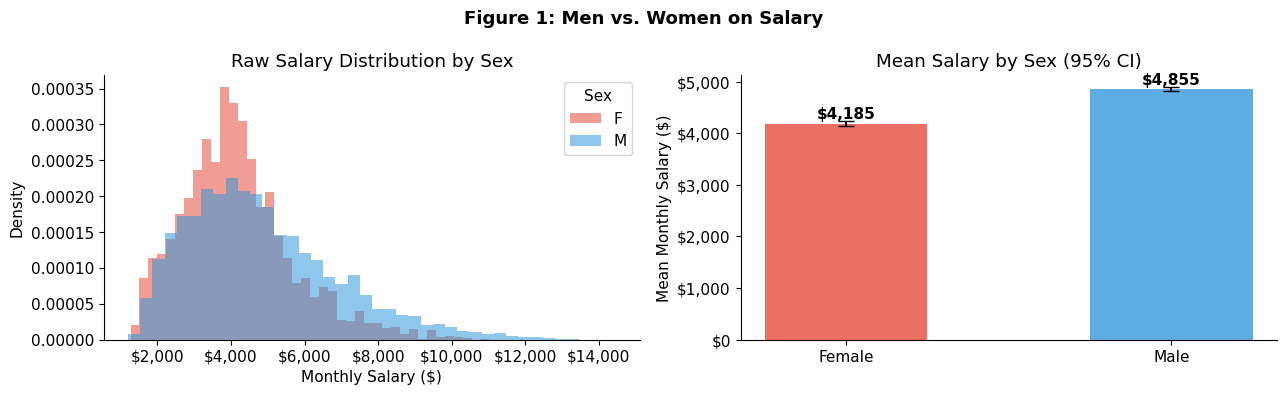

In [4]:
# ── Figure 1: Raw salary distributions ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for sex, grp in df_clean.groupby('sex', observed=True):
    axes[0].hist(grp['salary'], bins=40, alpha=0.55, color=COLORS[sex], label=sex, density=True)
axes[0].set_title('Raw Salary Distribution by Sex')
axes[0].set_xlabel('Monthly Salary ($)')
axes[0].set_ylabel('Density')
axes[0].legend(title='Sex')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

means = df_clean.groupby('sex', observed=True)['salary'].mean()
sems  = df_clean.groupby('sex', observed=True)['salary'].sem()
axes[1].bar(['Female','Male'], means.values, yerr=1.96*sems.values,
            color=['#e74c3c','#3498db'], alpha=0.8, capsize=6, width=0.5)
axes[1].set_title('Mean Salary by Sex (95% CI)')
axes[1].set_ylabel('Mean Monthly Salary ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
for i, (v, s) in enumerate(zip(means.values, sems.values)):
    axes[1].text(i, v + 1.96*s + 50, f'${v:,.0f}', ha='center', fontweight='bold')

plt.suptitle('Figure 1: Men vs. Women on Salary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Figure 1 offers a first look at the raw salary landscape across sexes. The distribution plot reveals that while both men and women are most densely concentrated around the **$3,000–$5,000** monthly salary range, the male distribution has a notably **longer right tail** — meaning men are disproportionately represented at higher salary levels beyond $6,000/month.

This is further confirmed by the mean salary comparison, where men earn an average of **$4,855/month** compared to **$4,185/month** for women , a raw gap of approximately **$670/month**. The narrow confidence intervals on both bars indicate these estimates are highly precise given the large sample size. 

At face value, a clear salary advantage exists for men — but whether this gap is driven by sex itself or by compositional differences in rank, field, and experience is what the analysis ahead seeks to unpack.

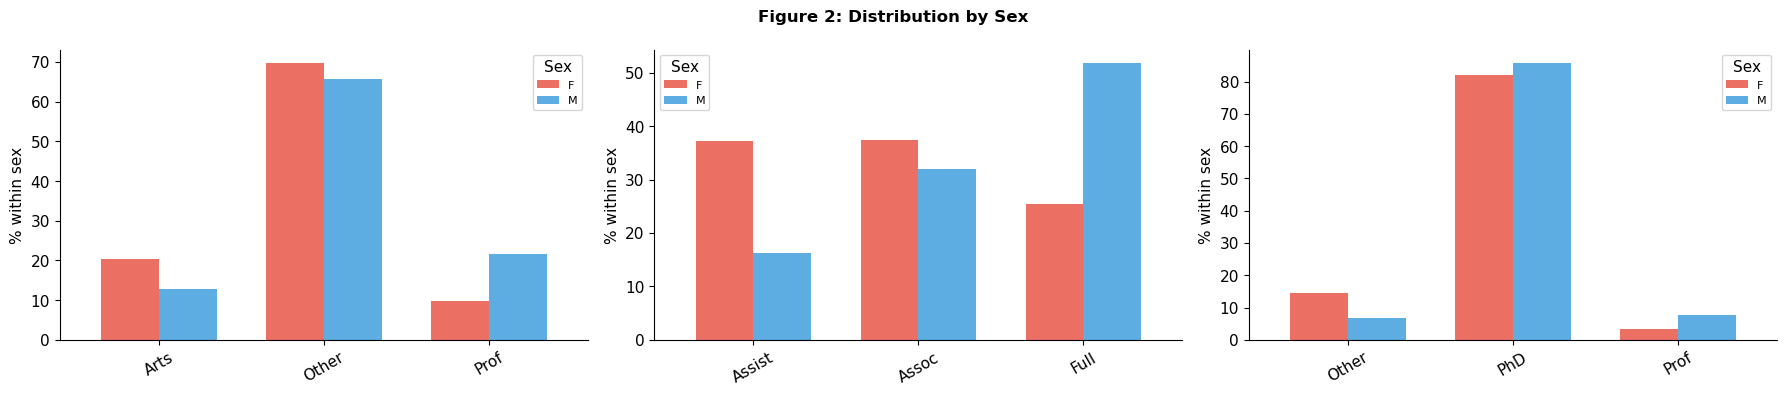

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, var, title in [
    (axes[0], 'field', 'Field'),
    (axes[1], 'rank',  'Rank'),
    (axes[2], 'deg',   'Degree'),
]:
    ct = pd.crosstab(df_clean[var], df_clean['sex'], normalize='columns') * 100
    chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(df_clean[var], df_clean['sex']))
    ct.plot(kind='bar', ax=ax, color=['#e74c3c','#3498db'], alpha=0.8, width=0.7)
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    ax.set_ylabel('% within sex'); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Sex', fontsize=8)

plt.suptitle('Figure 2: Distribution by Sex',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Figure 2 breaks down how men and women are distributed across field, rank, and degree revealing structural differences that likely contribute to the raw pay gap observed earlier.

**By Field:** Both sexes are predominantly concentrated in the "Other" category (~70% for women, ~65% for men). However, men are notably more represented in **professional fields (~22%)** compared to women (~10%), while women have a higher presence in **Arts (~21%)** versus men (~13%). Since professional fields tend to command higher salaries, this alone
could partially explain the pay gap.

**By Rank:** The rank distribution tells a particularly compelling story. Women are more heavily concentrated at the **Assistant (~38%) and Associate (~38%) levels**, while men are disproportionately represented at the **Full Professor level (~51%)** compared to women (~26%). Since full professors earn significantly more, this seniority gap is likely a major
driver of the salary disparity.

**By Degree:** Both sexes are overwhelmingly PhD holders (~82% women, ~84% men), so degree attainment is largely similar across sexes and is unlikely to be a major explanatory factor. Women do show a higher share of "Other" degrees (~15% vs ~6%), while men have a slightly higher representation in professional degrees.

Taken together, these distributions suggest that **rank and field composition** — not just sex — may be key structural forces behind the observed salary differences, warranting closer examination in the regression analysis ahead.

With these structural patterns in mind, we now dive deeper — examining sex-based differences at each critical junction of an employee's professional life within the institution.



# Where It All Begins: Starting Salaries

An employee's journey in any institution begins with a single number — their **starting salary**. This number is not just a figure on a contract; it is the foundation upon which every future raise, promotion, and financial decision is built. A disparity introduced at this stage does not stay contained — it **compounds over time**, widening the gap with every percentage-based raise and bonus that follows.

This is precisely why starting salaries are one of the most consequential and closely scrutinized points in any pay equity analysis. If sex influences what an employee is offered on day one — before they have had the chance to demonstrate performance, accumulate experience, or climb the ranks — then the institution has already failed the test of fairness. What follows is an examination of whether that is the case here.

# **QUESTION 1**: Wage Discrimination in Starting Salaries

Does wage discrimination exist in the starting salaries of faculty members (i.e., salaries in the year they were hired)?

First, we assessed whether wage discrimination exists in starting salaries. To address this question, we began by narrowing the dataset by filtering it to include only observations where the recorded year equals the starting year. This allows us to focus strictly on starting salaries.

Please note that we will use **women/females** and **men/males** interchangeably throughout this analysis.

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import scipy.stats as stats
import scipy.stats as ttest_ind
import warnings
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None
salaries = pd.read_csv("salary.txt", sep=r"\s+")

In [12]:
#Filtering out starting salaries 
starting_salaries = salaries[salaries["year"] == salaries["startyr"]].copy()

To address this question, we will break down our steps as follows:

1. Conduct exploratory analysis of the data using visualizations.
2. Compute numerical summaries of the data to gain a general understanding of it.
3. Conduct statistical analyses, including multiple linear regressions, ANOVA tests, permutation tests, and residual tests, to evaluate whether wage discrimination exists in starting salaries.
4. Finally, narrow down the analysis within one group.

From here, to get an idea of what the data looks like, we conducted an exploratory analysis for this question. We began by plotting the starting salary by sex.

[]

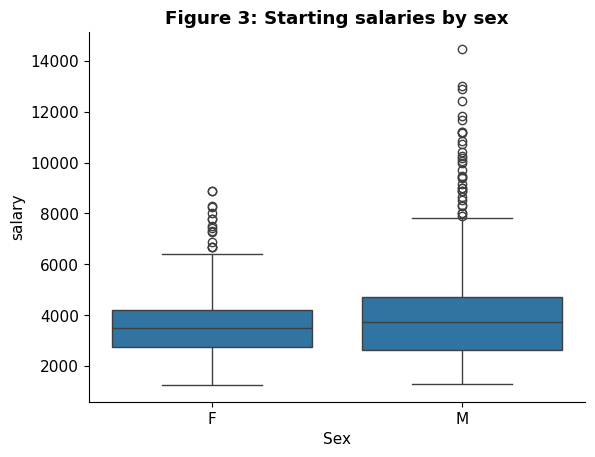

In [14]:
# Generally plotting salaries for each sex to see if there is an observable difference.
sns.boxplot(data = starting_salaries, x = "sex", y ="salary")
plt.xlabel("Sex")
plt.title ("Figure 3: Starting salaries by sex",fontweight='bold')
plt.plot()

In Figure 3, there are observable differences in the starting salaries of men versus women. We can also observe that there are more data points for men than for women. Finally, we can see that the average salary of men is slightly higher than that of women. However, these differences in starting salaries might not be strictly due to gender, as other factors may also affect starting salary.

With this, we conducted further exploratory analysis to examine how starting salaries relate to other factors, such as rank and field they are in, to assess whether additional factors may be affecting starting salaries.

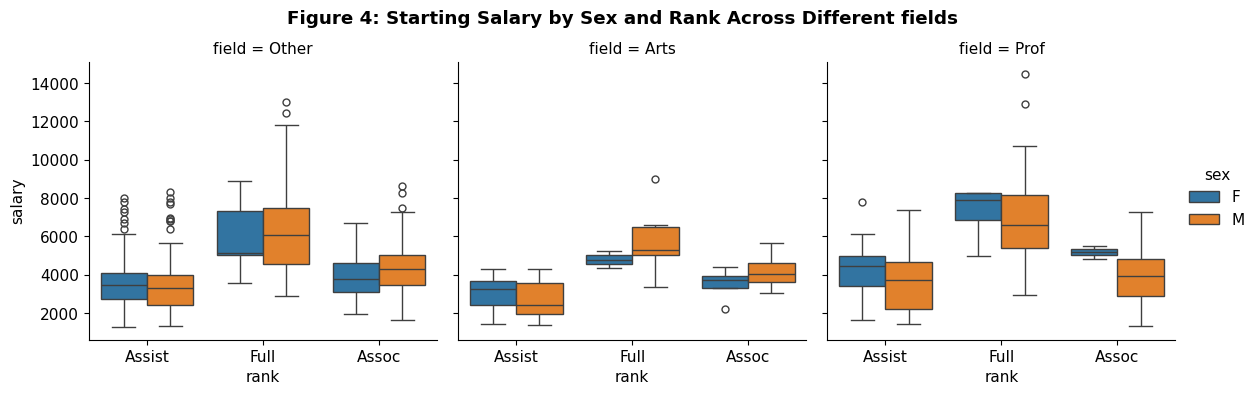

In [15]:
#Now doing some data exploration to observe for any patterns in the data before we start using numerical methos.
g = sns.catplot(
    data=starting_salaries,
    x="rank",
    y="salary",
    col="field",
    hue="sex",
    kind="box",
    height=4,
    aspect=1
)

g.fig.suptitle("Figure 4: Starting Salary by Sex and Rank Across Different fields", fontweight='bold')

g.fig.subplots_adjust(top=0.85)  # pushes plots down

plt.show()

Now, since the number of years since one's highest degree (which may also reflect years spent in the industry) could affect starting salary, we created a new field called `years_since_degree` to examine whether there is any observable pattern between experience and starting salary.

This field helps us observe potential relationships between time spent before being hired after degree, starting salary, and sex.

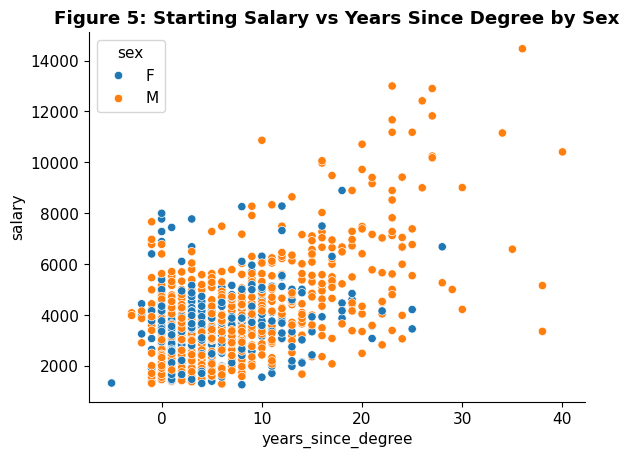

In [16]:
starting_salaries["years_since_degree"] = starting_salaries["startyr"] - starting_salaries["yrdeg"]
sns.scatterplot(data = starting_salaries, x = "years_since_degree", y = "salary", hue = "sex")
plt.title("Figure 5: Starting Salary vs Years Since Degree by Sex", fontweight='bold')  
plt.show()

From here, since we now have an idea of what the data looks like and have observed a difference in starting salaries by sex, we will now conduct numerical summaries to obtain quantitative context for the data.

## 2. Numerical summaries

First, we compute the mean and median of starting salaries by sex.

In [18]:
# Getting numeric summary statistics for salaries by sex
starting_salary_summary = starting_salaries.groupby("sex").agg(
    median_salary=("salary", "median"),
    mean_salary=("salary", "mean"),
    count=("salary", "count")
).reset_index() 
print (starting_salary_summary)

  sex  median_salary  mean_salary  count
0   F         3502.5  3600.322901    354
1   M         3719.0  4015.545388    753


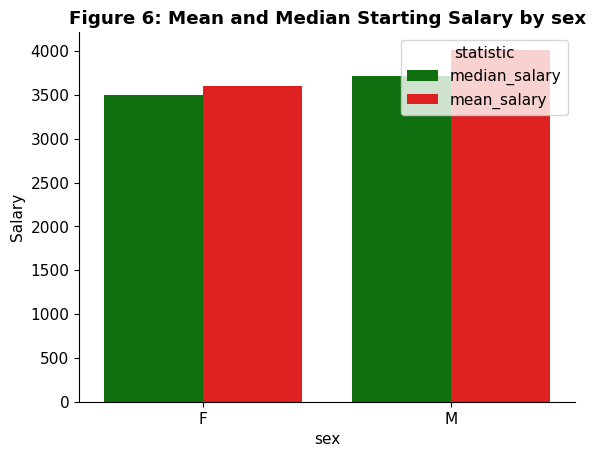

In [19]:

starting_salary_melted = starting_salary_summary.melt(
    id_vars='sex', 
    value_vars=['median_salary', 'mean_salary'], 
    var_name='statistic', 
    value_name='salary'
)

sns.barplot(data=starting_salary_melted, x='sex', y='salary', hue='statistic', palette=['green','red'])
plt.title("Figure 6: Mean and Median Starting Salary by sex", fontweight='bold')
plt.ylabel("Salary")
plt.xlabel("sex")
plt.show()

From this, we first observe that there are more data points for men, with about 399 more records than for women. Second, in terms of the median, men earn about 217 more than women. Finally, in terms of the mean, men earn about \$415 more than women.

Before running any models, we will assess the correlation between sex and starting salary to evaluate whether sex is a strong predictor of starting salary.

In [20]:
starting_salaries['sex_numeric'] = starting_salaries['sex'].map({'F': 0, 'M': 1}) 
correlation = starting_salaries['salary'].corr(starting_salaries['sex_numeric']) 
print("Correlation between starting salary and sex:", correlation)

Correlation between starting salary and sex: 0.10901192566702936


After checking the correlation between sex and starting salary, we observe a very weak positive association of 0.1, with males earning more on average.

## 3. Statistical Methods

Given these observations, we note that there is still a correlation. We now want to determine whether this difference remains after accounting for other relevant factors.

First, we will use a multiple linear regression model predicting starting salary from sex, field, degree, years_since_degree, rank, and admin.
`salary ~ sex + field + deg + years_since_degree + rank + admin`  


In [21]:
model = smf.ols(
    "salary ~ sex + field + deg + years_since_degree + rank + admin",
    data=starting_salaries
).fit()

# 1. Map to Human-Readable Labels for the Executive Report
name_map_start = {
    'Intercept': 'Baseline Constant',
    'sex[T.M]': 'Sex: Male (Ref: Female)',
    'field[T.Other]': 'Field: Other',
    'field[T.Prof]': 'Field: Professional',
    'deg[T.PhD]': 'Degree: PhD',
    'deg[T.Prof]': 'Degree: Professional',
    'rank[T.Assoc]': 'Rank: Associate Professor',
    'rank[T.Full]': 'Rank: Full Professor',
    'years_since_degree': 'Years Since Degree',
    'admin': 'Administrative Duties'
}

# 2. Extract results and map names
results_start = pd.DataFrame({
    'Variable': model.model.exog_names,
    'Coefficient': model.params.values,
    'Std. Error': model.bse.values,
    'P-Value': model.pvalues.values
})
results_start['Variable'] = results_start['Variable'].map(name_map_start).fillna(results_start['Variable'])

# 3. Sort by P-Value (Ascending)
results_start_sorted = results_start.sort_values(by="P-Value", ascending=True)

# 4. Generate Styled HTML
styled_start_table = (results_start_sorted.style
    .format({
        'Coefficient': '${:,.2f}',
        'Std. Error': '{:.2f}',
        'P-Value': '{:.4f}'
    })
    # Apply light red/pink highlighting to the 'Sex: Male' row specifically if it's significant
    .apply(lambda x: ['background-color: #f8d7da' if 'Sex: Male' in str(x['Variable']) and x['P-Value'] < 0.05 else '' for _ in x], axis=1)
    # Apply light green to all other significant rows
    .apply(lambda x: ['background-color: #e6ffed' if 'Sex: Male' not in str(x['Variable']) and x['P-Value'] < 0.05 else '' for _ in x], axis=1)
    .set_caption("<b>Table 1: Regression Analysis of Starting Salary Determinants (Sorted by Significance)</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#343a40'), ('color', 'white'), ('font-weight', 'bold'), ('border', '1px solid #ccc')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.25em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)
start_diagnostics = pd.DataFrame({
    "Metric": [
        "R-Squared (Explanatory Power)", 
        "Adjusted R-Squared", 
        "F-Statistic (Overall Significance)", 
        "Number of Observations",
        "Log-Likelihood"
    ],
    "Value": [
        f"{model.rsquared:.4f}", 
        f"{model.rsquared_adj:.4f}", 
        f"{model.f_pvalue:.4e}", 
        f"{int(model.nobs):,}",
        f"{model.llf:,.2f}"
    ]
})
# Style the Diagnostics Table to match Table 1
styled_start_diag = (start_diagnostics.style
    .set_caption("<b>Table 1b: Model Fit Diagnostics for Starting Salaries</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#495057'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.1em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)

display(styled_start_table)
display(styled_start_diag)

Variable,Coefficient,Std. Error,P-Value
Baseline Constant,"$2,378.99",175.75,0.0000
Rank: Full Professor,"$2,134.69",199.80,0.0000
Years Since Degree,$70.37,9.45,0.0000
Field: Professional,$859.93,156.18,0.0000
Field: Other,$469.38,131.68,0.0004
Rank: Associate Professor,$389.62,132.50,0.0033
Degree: PhD,$385.28,155.14,0.0132
Degree: Professional,$508.41,222.32,0.0224
Sex: Male (Ref: Female),$-147.11,94.01,0.1179
Administrative Duties,$31.11,225.96,0.8905


Metric,Value
R-Squared (Explanatory Power),0.3875
Adjusted R-Squared,0.3824
F-Statistic (Overall Significance),2.1450e-110
Number of Observations,"1,107"
Log-Likelihood,"-9,582.47"


The results show that sex alone is not a statistically significant predictor of starting salary when controlling for these variables. In the baseline model, men appear to earn about \$147 less than women, but this difference is not statistically significant (p = 0.118). 

Instead, the strongest predictors of starting salary are rank, field, and years since attaining the highest degree. Statistically significant factors (p < 0.05) include:

- Faculty in professional fields earning about \$860 more than those in arts.
- Full professors earning about \$2,135 more than assistant professors.
- Each additional year after attaining the highest degree increasing salary by about \$70.

Next, we run an ANOVA test to check whether including sex contributes to model performance. We do this by comparing a full model that includes all predictors with a reduced model that excludes sex.

- **Full model:** `salary ~ sex + field + deg + years_since_degree + rank + admin`  
- **Reduced model:** `salary ~ field + deg + years_since_degree + rank + admin`

In [22]:
# Test removing sex
model_full = smf.ols(
    "salary ~ sex + field + deg + years_since_degree + rank + admin",
    data=starting_salaries
).fit()

model_reduced_sex = smf.ols(
    "salary ~ field + deg + years_since_degree + rank + admin",
    data=starting_salaries
).fit()

anova_results = anova_lm(model_reduced_sex, model_full)

# 2. Format the results for a professional table
# We pull the specific row comparing the two models
anova_df = pd.DataFrame({
    "Comparison": ["Model without sex vs. Full Model"],
    "Sum of Squares Diff": [anova_results.loc[1, 'ss_diff']],
    "DF Diff": [int(anova_results.loc[1, 'df_diff'])],
    "F-Statistic": [anova_results.loc[1, 'F']],
    "P-Value": [anova_results.loc[1, 'Pr(>F)']]
})

# 3. Styled HTML Output
styled_anova = (anova_df.style
    .format({
        'Sum of Squares Diff': '{:,.2f}',
        'F-Statistic': '{:.4f}',
        'P-Value': '{:.4f}'
    })
    .set_caption("<b>Table 1c: ANOVA F-Test - Impact of Sex on Starting Salaries</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '12px')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'caption', 'props': [('font-size', '1.1em'), ('font-weight', 'bold'), ('margin-bottom', '10px')]}
    ])
    .hide(axis='index')
    # Apply highlight if significant
    .apply(lambda x: ['background-color: #e6ffed' if x['P-Value'] < 0.05 else 'background-color: #f8d7da' for _ in x], axis=1)
)

styled_anova

Comparison,Sum of Squares Diff,DF Diff,F-Statistic,P-Value
Model without sex vs. Full Model,"4,777,296.66",1,2.4490,0.1179


From the above, we observe a p-value of 0.118, which means that removing sex does not significantly affect starting salaries in the non-interactive model.

However, this does not tell the full story. Next, we run an interactive model to examine how sex interacts with other factors. This model helps us assess whether any interactions between predictors and sex exist.

These interactions can reveal if there are any patterns that might indicate starting salary discrimination by sex.

In [23]:
#Interactive model

model2 = smf.ols(
    "salary ~ sex * (field + deg + years_since_degree + rank)",
    data=starting_salaries
).fit()

# Extracting coefficients table
results_df = pd.DataFrame({
    "coef": model2.params,
    "p_value": model2.pvalues,
    "t_value": model2.tvalues
})

# Sorting by p-value ascending to see if there is any sex interaction that is significant
results_df_sorted = results_df.sort_values(by="p_value", ascending=True)

# 1. Map to Human-Readable Labels
name_map = {
    'Intercept': 'Baseline Constant',
    'C(sex)[T.M]': 'Sex: Male (Ref: Female)',
    'C(field)[T.Other]': 'Field: Other',
    'C(field)[T.Prof]': 'Field: Professional',
    'C(deg)[T.PhD]': 'Degree: PhD',
    'C(deg)[T.Prof]': 'Degree: Professional',
    'yrdeg': 'Year of Degree',
    'admin': 'Administrative Duties',
    'years_since_degree': 'Years Since Degree',
    'years_at_inst': 'Years at Institution'
}

# 2. Prepare the DataFrame for the HTML view
# Resetting index turns the variable names into a styleable column
results_final = results_df.copy().reset_index()
results_final.rename(columns={'index': 'Variable'}, inplace=True)
results_final['Variable'] = results_final['Variable'].map(name_map).fillna(results_final['Variable'])

# 3. Sort by p_value (Ascending)
results_final = results_final.sort_values(by="p_value", ascending=True)

# 4. Generate Styled HTML
styled_table = (results_final.style
    .format({
        'coef': '{:.4f}',
        'p_value': '{:.4f}',
        't_value': '{:.2f}'
    })
    # Apply light green highlighting to significant rows (p < 0.05)
    .apply(lambda x: ['background-color: #e6ffed' if x['p_value'] < 0.05 else '' for _ in x], axis=1)
    # Add a bold border to separate the Variable names
    .set_properties(subset=['Variable'], **{'font-weight': 'bold', 'border-right': '1px solid #ccc'})
    .set_caption("<b>Table 2: Significant Predictors of Promotion Salary Increase (Sorted by P-Value)</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f8f9fa'), ('color', '#333'), ('border', '1px solid #ccc'), ('padding', '12px')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.25em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)
# Create the Diagnostic DataFrame for the Interaction Model
interaction_diagnostics = pd.DataFrame({
    "Metric": [
        "R-Squared (Explanatory Power)", 
        "Adjusted R-Squared", 
        "F-Statistic P-Value", 
        "Number of Observations",
        "AIC (Akaike Information Criterion)"
    ],
    "Value": [
        f"{model2.rsquared:.4f}", 
        f"{model2.rsquared_adj:.4f}", 
        f"{model2.f_pvalue:.4e}", 
        f"{int(model2.nobs):,}",
        f"{model2.aic:,.2f}"
    ]
})
styled_interaction_diag = (interaction_diagnostics.style
    .set_caption("<b>Table 2b: Interaction Model Fit Diagnostics</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#495057'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.1em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)

display(styled_table)
display(styled_interaction_diag)

Variable,coef,p_value,t_value
Baseline Constant,2767.7577,0.0000,10.54
rank[T.Full],2514.0800,0.0000,5.99
field[T.Prof],1059.4832,0.0004,3.54
sex[T.M]:years_since_degree,73.5542,0.0005,3.49
deg[T.Prof],1060.8552,0.0095,2.60
field[T.Other],403.5185,0.0359,2.10
sex[T.M],-679.9913,0.0517,-1.95
rank[T.Assoc],449.4094,0.0911,1.69
sex[T.M]:deg[T.Prof],-748.2440,0.1276,-1.52
sex[T.M]:rank[T.Full],-623.1070,0.1880,-1.32


Metric,Value
R-Squared (Explanatory Power),0.3983
Adjusted R-Squared,0.3900
F-Statistic P-Value,3.9030e-109
Number of Observations,"1,107"
AIC (Akaike Information Criterion),"19,177.15"


We then observe that sex is only significant when interacting with years since degree (p = 5.07e-04).

Additionally, sex alone is almost significant, with a p-value of 0.0517, which is close enough to warrant consideration.

Therefore, we will perform a permutation test to determine whether the observed differences in starting salaries could occur by chance if sex were randomly assigned.

The null hypothesis for this test is that **"There is no difference between the starting salaries of males and females."**

In [24]:
#Observed difference in means (M - F)
obs_diff = (
    starting_salaries[starting_salaries["sex"] == "M"]["salary"].mean()
    - starting_salaries[starting_salaries["sex"] == "F"]["salary"].mean()
)

print(obs_diff)

415.22248665226107


In [25]:
# Permutation test
np.random.seed(123)

perm_diffs = []

for _ in range(5000):
    shuffled_sex = np.random.permutation(starting_salaries["sex"])
    
    diff = (
        starting_salaries["salary"][shuffled_sex == "M"].mean()
        - starting_salaries["salary"][shuffled_sex == "F"].mean()
    )
    
    perm_diffs.append(diff)

perm_diffs = np.array(perm_diffs)

p_value = np.mean(np.abs(perm_diffs) >= abs(obs_diff))
print (f'permutation p-value: {p_value}')

permutation p-value: 0.0004


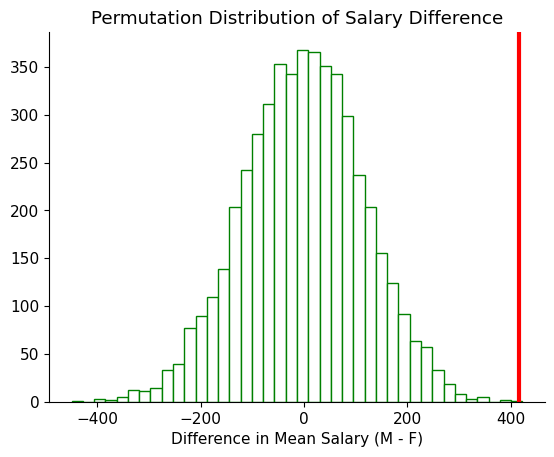

In [26]:
# Histogram of permutation distribution
plt.hist(perm_diffs, bins=40, color='white', edgecolor='green')
plt.axvline(obs_diff, linewidth=3, color='red')
plt.title("Permutation Distribution of Salary Difference")
plt.xlabel("Difference in Mean Salary (M - F)")
plt.show()

From this, we can conclude that the average salary difference of \$415 between males and females is extremely unlikely to occur by chance.

Given that the null hypothesis in the permutation test states that there is no difference between the starting salaries of males and females, and our p-value is < 0.05, we reject the null hypothesis.

Therefore, the observed difference is highly unlikely to happen if sex had no effect on starting salaries.

Now, let's examine whether the unexplained salary differences (residuals) still differ between males and females after controlling for rank, field, degree, years since degree, and admin.

In [27]:
from scipy.stats import ttest_ind

lm_base = smf.ols(
    "salary ~ rank + field + deg + yrdeg + admin + years_since_degree",
    data=starting_salaries
).fit()

residuals = lm_base.resid
residuals_f = residuals[starting_salaries["sex"] == "F"]
residuals_m = residuals[starting_salaries["sex"] == "M"]

# Welch's t-test (unequal variance)
result_residuals = ttest_ind(residuals_m, residuals_f, equal_var=False)

print(f"T-statistic: {result_residuals.statistic:.3f}")
print(f"P-value: {result_residuals.pvalue:.6f}")

T-statistic: 3.208
P-value: 0.001383


From the analysis, we observe a statistically significant result (t = 3.208, p = 0.00138), indicating that differences remain even after controlling for the other variables.

Overall, while rank, field, and years since attaining the highest degree explain most of the variation in starting salaries, the results suggest that the observed difference between male and female starting salaries is unlikely to occur purely by chance. 

Based on this, we believe that while sex may not be a very strong predictor overall, differences may become clearer within specific subgroups of the data, such as when examining starting salaries within a particular rank (e.g., associate professors).

### Sex by Rank

In [28]:
#Select assistant professors in their first year
assist_prof_subset = starting_salaries[
    (starting_salaries["rank"] == "Assist") &
    (starting_salaries["startyr"] == starting_salaries["year"])
].copy()

In [29]:
#convert columns so they can go into the regression model
categorical_cols = ["admin", "sex", "field", "deg"]
for col in categorical_cols:
    assist_prof_subset[col] = assist_prof_subset[col].astype("category")

In [30]:
#Assist prof model (dropped admin bc only 1 point was admin == 1)
assist_lm = smf.ols(
    "salary ~ sex + field + deg + yrdeg + year",
    data=assist_prof_subset
).fit()

# 1. Extract results from the Assistant Professor OLS model
assist_results = pd.DataFrame({
    'Variable': assist_lm.model.exog_names,
    'Coefficient': assist_lm.params.values,
    'Std. Error': assist_lm.bse.values,
    't-statistic': assist_lm.tvalues.values,
    'P-Value': assist_lm.pvalues.values
})

# 2. Map to Human-Readable Names for administrators
name_map_assist = {
    'Intercept': 'Baseline Constant',
    'sex[T.M]': 'Sex: Male (Ref: Female)',
    'field[T.Other]': 'Field: Other (Ref: Arts)',
    'field[T.Prof]': 'Field: Professional',
    'deg[T.PhD]': 'Degree: PhD',
    'deg[T.Prof]': 'Degree: Professional',
    'yrdeg': 'Years Since Degree',
    'year': 'Year of Data Entry'
}
assist_results['Variable'] = assist_results['Variable'].map(name_map_assist)

# 3. Create the Styled HTML Table
styled_assist_table = (assist_results.style
    .format({
        'Coefficient': '${:,.2f}',
        'Std. Error': '{:.2f}',
        't-statistic': '{:.2f}',
        'P-Value': '{:.4f}'
    })
    # Highlight the Sex row to draw the administrator's eye
    .apply(lambda x: ['background-color: #f8d7da' if 'Sex: Male' in str(v) else '' for v in x], axis=1)
    .set_caption("Table 3: Analysis of Starting Salaries for Assistant Professors")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#343a40'), ('color', 'white'), ('font-family', 'Arial')]},
        {'selector': 'td', 'props': [('border', '1px solid #dee2e6'), ('padding', '8px')]}
    ])
    .hide(axis='index')
)
# Create the Diagnostic DataFrame for Assistant Professors
assist_diagnostics = pd.DataFrame({
    "Metric": [
        "R-Squared (Explanatory Power)", 
        "Adjusted R-Squared", 
        "F-Statistic P-Value", 
        "Observations (Assistant Profs)",
        "Log-Likelihood"
    ],
    "Value": [
        f"{assist_lm.rsquared:.4f}", 
        f"{assist_lm.rsquared_adj:.4f}", 
        f"{assist_lm.f_pvalue:.4e}", 
        f"{int(assist_lm.nobs):,}",
        f"{assist_lm.llf:,.2f}"
    ]
})
# Style the Diagnostics Table to match your Assistant Prof Table
styled_assist_diag = (assist_diagnostics.style
    .set_caption("<b>Table 3b: Assistant Professor Model Fit Diagnostics</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#495057'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #dee2e6'), ('padding', '8px')]},
        {'selector': 'caption', 'props': [('font-size', '1.1em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)


display(styled_assist_table)
display(styled_assist_diag)

Variable,Coefficient,Std. Error,t-statistic,P-Value
Baseline Constant,"$-11,705.57",385.71,-30.35,0.0000
Sex: Male (Ref: Female),$116.83,52.66,2.22,0.0268
Field: Other (Ref: Arts),$337.36,71.17,4.74,0.0000
Field: Professional,$855.88,87.25,9.81,0.0000
Degree: PhD,$-49.19,90.83,-0.54,0.5883
Degree: Professional,$679.72,134.84,5.04,0.0000
Years Since Degree,$10.80,6.07,1.78,0.0757
Year of Data Entry,$158.20,7.00,22.61,0.0000


Metric,Value
R-Squared (Explanatory Power),0.6843
Adjusted R-Squared,0.6815
F-Statistic P-Value,5.9575e-194
Observations (Assistant Profs),802
Log-Likelihood,"-6,382.30"


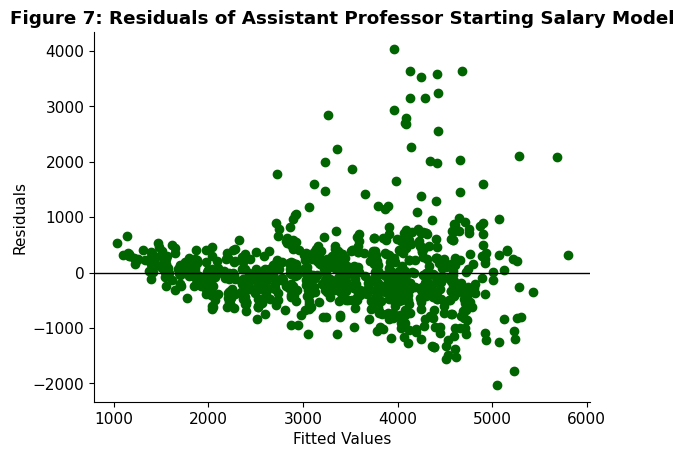

In [31]:
#Check residuals + plot
Q1_assist_residuals = assist_lm.resid
fitted_values = assist_lm.fittedvalues

plt.scatter(fitted_values, Q1_assist_residuals, color='darkgreen')
plt.axhline(0, color='black', linewidth=1)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Figure 7: Residuals of Assistant Professor Starting Salary Model", fontweight='bold')
plt.show()

In [32]:
#Apply robust standard errors
robust_se = assist_lm.get_robustcov_results(cov_type='HC3')

# 1. Extract results from the robust model
robust_results = pd.DataFrame({
    'Variable': robust_se.model.exog_names,
    'Coefficient': robust_se.params,
    'Robust Std. Error': robust_se.bse,
    't-statistic': robust_se.tvalues,
    'P-Value': robust_se.pvalues
})

# 2. Map to Human-Readable Names for policymakers
name_map_robust = {
    'Intercept': 'Baseline Constant',
    'sex[T.M]': 'Sex: Male (vs. Female)',
    'field[T.Other]': 'Field: Other (Ref: Arts)',
    'field[T.Prof]': 'Field: Professional',
    'deg[T.PhD]': 'Degree: PhD',
    'deg[T.Prof]': 'Degree: Professional',
    'yrdeg': 'Year of Degree',
    'year': 'Year of Data Point'
}
robust_results['Variable'] = robust_results['Variable'].map(name_map_robust)

# 3. Create the Styled HTML Table
styled_robust_table = (robust_results.style
    .format({
        'Coefficient': '{:.2f}',
        'Robust Std. Error': '{:.2f}',
        't-statistic': '{:.2f}',
        'P-Value': '{:.4f}'
    })
    .apply(lambda x: ['background-color: #d1ecf1' if 'Sex: Male' in str(v) else '' for v in x], axis=1) # Highlight Gender Row
    .set_caption("Table 4: Robust Regression of Starting Salaries (Assistant Professors)")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#17a2b8'), ('color', 'white'), ('padding', '10px')]},
        {'selector': 'td', 'props': [('border', '1px solid #dee2e6'), ('padding', '8px')]}
    ])
    .hide(axis='index')
)
robust_diagnostics = pd.DataFrame({
    "Metric": [
        "R-Squared (Explanatory Power)", 
        "Adjusted R-Squared", 
        "F-Statistic (Robust)", 
        "Prob (F-statistic)",
        "Covariance Type",
        "Observations"
    ],
    "Value": [
        f"{robust_se.rsquared:.4f}", 
        f"{robust_se.rsquared_adj:.4f}", 
        f"{robust_se.fvalue:.2f}", 
        f"{robust_se.f_pvalue:.4e}",
        "HC3 (Robust)",
        f"{int(robust_se.nobs):,}"
    ]
})
# Style the Diagnostics Table to match your Robust Table
styled_robust_diag = (robust_diagnostics.style
    .set_caption("<b>Table 4b: Robust Model Fit & Reliability Metrics</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#138496'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #dee2e6'), ('padding', '8px')]},
        {'selector': 'caption', 'props': [('font-size', '1.1em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)

display(styled_robust_table)
display(styled_robust_diag)

Variable,Coefficient,Robust Std. Error,t-statistic,P-Value
Baseline Constant,-11705.57,359.34,-32.58,0.0000
Sex: Male (vs. Female),116.83,53.02,2.20,0.0278
Field: Other (Ref: Arts),337.36,44.79,7.53,0.0000
Field: Professional,855.88,64.42,13.29,0.0000
Degree: PhD,-49.19,76.44,-0.64,0.5201
Degree: Professional,679.72,136.36,4.98,0.0000
Year of Degree,10.80,5.77,1.87,0.0616
Year of Data Point,158.20,6.02,26.30,0.0000


Metric,Value
R-Squared (Explanatory Power),0.6843
Adjusted R-Squared,0.6815
F-Statistic (Robust),279.08
Prob (F-statistic),3.7740e-209
Covariance Type,HC3 (Robust)
Observations,802


In [33]:
#Subset into female vs male
women_data = assist_prof_subset[assist_prof_subset["sex"] == "F"]
men_data = assist_prof_subset[assist_prof_subset["sex"] == "M"]

# Get the size of each just for reference
print(f"Women data points: {len(women_data)}")
print(f"Men data points: {len(men_data)}")

# Look at variance of men vs women salary for startyr
print(f"Women variance: {women_data['salary'].var()}")
print(f"Men variance: {men_data['salary'].var()}")

Women data points: 301
Men data points: 501
Women variance: 1376779.2061921281
Men variance: 1602759.3115676737


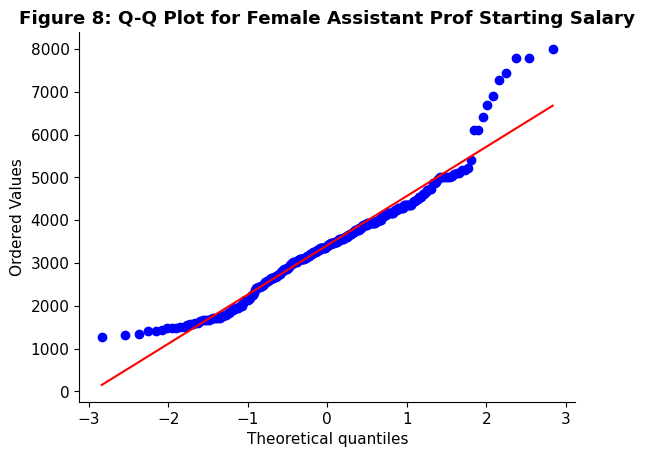

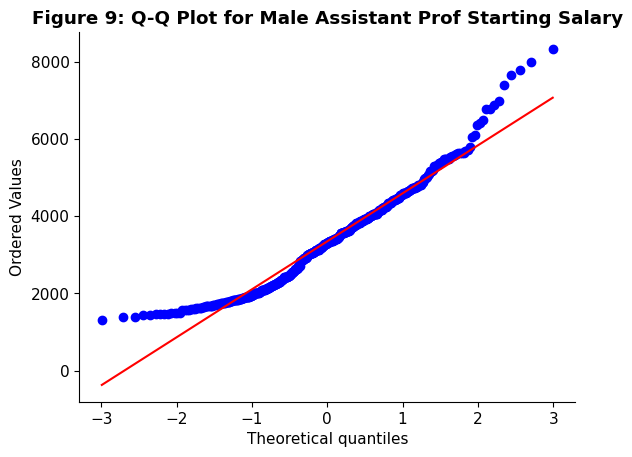

In [34]:
#Q-Q plots for starting salary
plt.figure()
stats.probplot(women_data["salary"], dist="norm", plot=plt)
plt.title("Figure 8: Q-Q Plot for Female Assistant Prof Starting Salary", fontweight='bold')
plt.show()

plt.figure()
stats.probplot(men_data["salary"], dist="norm", plot=plt)
plt.title("Figure 9: Q-Q Plot for Male Assistant Prof Starting Salary", fontweight='bold')
plt.show()

In [35]:
#Permutation test for Assistant Profs
obs_diff = men_data["salary"].mean() - women_data["salary"].mean()

np.random.seed(123)
perm_diffs = []

for _ in range(5000):
    shuffled_sex = np.random.permutation(assist_prof_subset["sex"])
    diff = (
        assist_prof_subset["salary"][shuffled_sex == "M"].mean()
        - assist_prof_subset["salary"][shuffled_sex == "F"].mean()
    )
    perm_diffs.append(diff)

perm_diffs = np.array(perm_diffs)
assist_p_value = np.mean(np.abs(perm_diffs) >= abs(obs_diff))
print(f"Permutation Test For Assistant Professors p-value: {assist_p_value}")

Permutation Test For Assistant Professors p-value: 0.4598


PLEASE GIVE A DETAILED SUMMARY FOR THIS 

# The Next Rung: Promotions & Salary Increments

Getting hired is only the beginning. As an employee grows within an institution, the next defining moment is **promotion** , the recognition of merit, contribution, and potential. But when the data is examined closely, a critical question emerges: is that recognition distributed equally, or does sex play a role in who gets elevated and how fast?

Promotions are not merely symbolic. Each rank advancement — from Assistant to Associate,from Associate to Full Professor — carries with it a **substantial salary jump**. An employee who is passed over, delayed, or systematically underrepresented at the higher ranks does not just lose a title. They lose **years of compounded higher earnings**, retirement contributions
calculated on a lower base, and the institutional visibility that comes with seniority.

We already saw in Figure 2 that men are disproportionately concentrated at the **Full Professor level**, while women cluster at the Assistant and Associate ranks. But is this purely a function of experience and time — or does sex itself accelerate or impede the climb?

Beyond promotions, we examine **salary increments** ,the year-over-year raises that reflect how an institution values its employees over time. Even if starting salaries were perfectly equal, a pattern of systematically smaller increments for one sex would silently erode equity with every passing year, leaving a growing gap that is invisible in any single snapshot but
damning when viewed across a career.

Together, promotions and increments tell the story of **whether fairness is sustained** or whether the institution's bias, if any, reveals itself not at the door, but on the way up.

# **Question 2**: Wage discrimination at promotion (Assoc → Full)

We first want to explore the question of are men being promoted more than women?

In [36]:
df_sorted = df.sort_values(["id", "year"])
rank_shift = df_sorted.groupby("id")["rank"].shift(1)
df_sorted["promo_event"] = (
    (rank_shift == "Assoc") & (df_sorted["rank"] == "Full") & (rank_shift != df_sorted["rank"])
)
promo_year = df_sorted.loc[df_sorted["promo_event"], ["id", "year"]].drop_duplicates("id").rename(columns={"year": "promo_year"})
people = df_sorted[["id", "sex", "yrdeg", "startyr"]].drop_duplicates("id").merge(promo_year, on="id", how="left")
people["yrs_to_promo"] = people["promo_year"] - people["startyr"]
people["promoted"] = people["promo_year"].notna()

promo_table = people.groupby("sex", observed=True)["promoted"].agg(["sum", "count"])
promo_table.columns = ["promoted", "n"]
promo_table["prop"] = promo_table["promoted"] / promo_table["n"]
# 1. Prepare the data for display
promo_display = promo_table.copy().reset_index()
promo_display['sex'] = promo_display['sex'].map({'F': 'Female', 'M': 'Male'})
promo_display.columns = ['Sex', 'Number Promoted', 'Total Senior Faculty', 'Promotion Rate']

# 2. Generate the Styled HTML Table with a Title
styled_promo_summary = (promo_display.style
    .format({'Promotion Rate': '{:.2%}'})
    .set_caption("<b>Table 10: Summary of Promotions (Associate to Full) by Gender</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#455a64'), ('color', 'white'), ('font-weight', 'bold'), ('padding', '12px')]},
        {'selector': 'td', 'props': [('border', '1px solid #cfd8dc'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'caption', 'props': [('font-size', '1.2em'), ('font-weight', 'bold'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
    # Highlight the Promotion Rate to draw the eye to the disparity
    .set_properties(subset=['Promotion Rate'], **{'background-color': '#e1f5fe', 'font-weight': 'bold'})
)

styled_promo_summary

Sex,Number Promoted,Total Senior Faculty,Promotion Rate
Female,100,409,24.45%
Male,446,1188,37.54%


From the table, we can see that there is a higher promotion rate for males than females. However, we want to also test to see if there is a significant increase in probability of being a Full professor for a male than a female.

Null Hypothesis: Men and Women are promoted to Full Professor at equal rates

In [49]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency

senior_faculty = df[df['rank'].isin(['Assoc', 'Full'])].copy()
senior_faculty['is_full'] = (senior_faculty['rank'] == 'Full').astype(int)

# 1. Logistic Regression: Probability of being 'Full' controlled for years since degree
logit_model = smf.logit('is_full ~ C(sex) + yrdeg + C(field)', data=senior_faculty).fit()

# 1. Extract results
logit_results = pd.DataFrame({
    'Variable': logit_model.params.index,
    'Coefficient (Log-Odds)': logit_model.params.values,
    'Std. Error': logit_model.bse.values,
    'P-Value': logit_model.pvalues.values
})

# 2. Calculate Odds Ratios (e^coef) - Crucial for non-statisticians
logit_results['Odds Ratio'] = np.exp(logit_results['Coefficient (Log-Odds)'])

# 3. Map to Human-Readable Names
name_map_logit = {
    'Intercept': 'Baseline Constant',
    'C(sex)[T.M]': 'Sex: Male (Ref: Female)',
    'C(field)[T.Other]': 'Field: Other (Ref: Arts)',
    'C(field)[T.Prof]': 'Field: Professional',
    'yrdeg': 'Year of Degree (Seniority)'
}
logit_results['Variable'] = logit_results['Variable'].map(name_map_logit)

# 4. Create the Styled HTML Table
nice_logit_table = (logit_results.style
    .format({
        'Coefficient (Log-Odds)': '{:.4f}',
        'Std. Error': '{:.4f}',
        'P-Value': '{:.4f}',
        'Odds Ratio': '{:.2f}x'
    })
    .apply(lambda x: ['background-color: #e6ffed' if v < 0.05 else '' for v in x], subset=['P-Value'])
    .set_caption("<b>Table 11: Probability of Attaining Full Professor Rank (Logistic Regression)</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '8px')]}
    ])
    .hide(axis='index')
)
# Create the Diagnostic DataFrame for the Logistic Model
logit_diagnostics = pd.DataFrame({
    "Metric": [
        "Pseudo R-Squared (McFadden)", 
        "LR Stat P-Value (Overall Fit)", 
        "Log-Likelihood", 
        "Observations (Senior Faculty)",
        "Convergence Success"
    ],
    "Value": [
        f"{logit_model.prsquared:.4f}", 
        f"{logit_model.llr_pvalue:.4e}", 
        f"{logit_model.llf:,.2f}", 
        f"{int(logit_model.nobs):,}",
        "Yes" if logit_model.mle_retvals['converged'] else "No"
    ]
})
# Style the Diagnostics Table to match Table 11
styled_logit_diag = (logit_diagnostics.style
    .set_caption("<b>Table 11b: Logistic Model Fit & Convergence Summary</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '8px')]},
        {'selector': 'caption', 'props': [('font-size', '1.1em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)

display(nice_logit_table)
display(styled_logit_diag)

Optimization terminated successfully.
         Current function value: 0.562602
         Iterations 6


Variable,Coefficient (Log-Odds),Std. Error,P-Value,Odds Ratio
Baseline Constant,9.8126,0.2298,0.0000,18261.75x
Sex: Male (Ref: Female),0.3342,0.0507,0.0000,1.40x
Field: Other (Ref: Arts),0.8554,0.0539,0.0000,2.35x
Field: Professional,1.2506,0.0657,0.0000,3.49x
Year of Degree (Seniority),-0.1499,0.0031,0.0000,0.86x


Metric,Value
Pseudo R-Squared (McFadden),0.1709
LR Stat P-Value (Overall Fit),0.0000e+00
Log-Likelihood,"-8,855.36"
Observations (Senior Faculty),"15,740"
Convergence Success,Yes


The p-value is less than 0.05 for the coefficient sex so we reject the null hypothesis that men and women are promoted at equal rates. Men are promoted at higher rates for the same seniority.

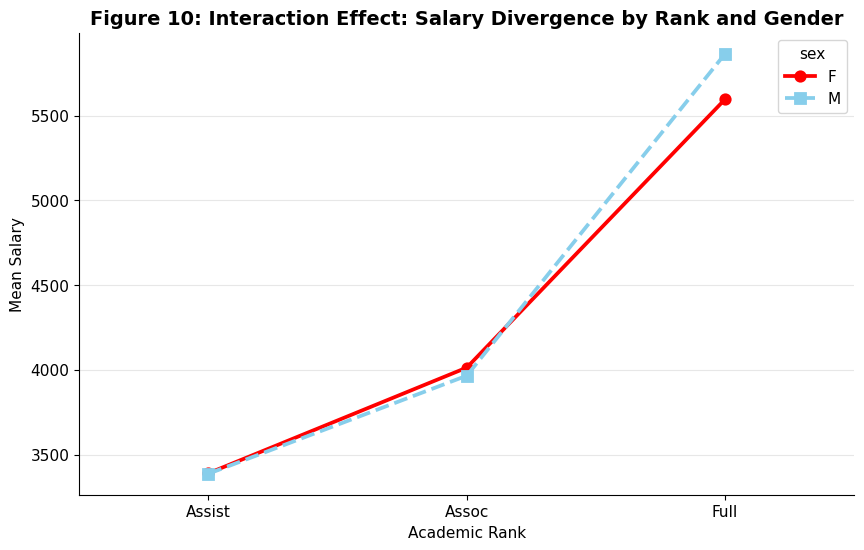

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean salaries by Rank and Sex
interaction_data = df.groupby(['rank', 'sex'])['salary'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.pointplot(data=interaction_data, x='rank', y='salary', hue='sex', 
              markers=["o", "s"], linestyles=["-", "--"], palette=['red', 'skyblue'])

plt.title('Figure 10: Interaction Effect: Salary Divergence by Rank and Gender', fontsize=14, fontweight='bold')
plt.ylabel('Mean Salary')
plt.xlabel('Academic Rank')
plt.grid(axis='y', alpha=0.3)
plt.show()

Knowing that males get promoted at a higher rate, we now want to explore the question: does sex-based wage discrimation exist in granting promotions from Associate Professor to Full Professor?

To answer this, we first need to define wage discrimination. We can think of it in two ways: differences by sex in salary increases from Associate Professor to Full Professor, and differences by sex in starting salary during the first year as a Full Professor.

In [44]:
raw = pd.read_csv("salary.txt", sep=r"\s+")
df = raw.copy()
for c in ["sex", "deg", "field", "rank"]:
    df[c] = df[c].astype("category")
for c in ["case", "id", "yrdeg", "startyr", "year", "admin"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")
df["salary"] = pd.to_numeric(df["salary"], errors="coerce")

## 1. Numerical summaries

Let’s first look at the numerical summaries and related statistics to see what the observations show.

In [45]:
# First, ensure the data is sorted by ID and Year
df_sorted = df.sort_values(['id', 'year'])

# Create a 'previous_rank' column to compare
df_sorted['prev_rank'] = df_sorted.groupby('id')['rank'].shift(1)

# Define the promo_event: 
# It's True if they are now 'Full' but were 'Assoc' in the previous record
df_sorted['promo_event'] = (df_sorted['prev_rank'] == 'Assoc') & (df_sorted['rank'] == 'Full')

In [46]:
first_full = (
    df_sorted[df_sorted["promo_event"]].drop_duplicates("id")
    [["id", "sex", "yrdeg", "startyr", "field", "deg", "admin", "year", "salary"]]
    .rename(columns={"year": "promo_year", "salary": "salary_full"})
)
assoc_before = (
    df_sorted[df_sorted["rank"] == "Assoc"].merge(first_full[["id", "promo_year"]], on="id")
    .query("year < promo_year").sort_values(["id", "year"]).groupby("id").tail(1)
    [["id", "salary", "year"]].rename(columns={"salary": "salary_assoc", "year": "assoc_year"})
)
promo_pay = first_full.merge(assoc_before, on="id", how="left")
promo_pay["salary_delta"] = promo_pay["salary_full"] - promo_pay["salary_assoc"]

salary_at_promo = promo_pay.dropna(subset=["salary_full", "salary_delta"]).groupby("sex")["salary_full"].agg(["mean", "median", "std", "count"])
salary_raise = promo_pay.dropna(subset=["salary_delta"]).groupby("sex")["salary_delta"].agg(["mean", "median", "std", "count"])
salary_at_promo["metric"] = "salary at first Full"
salary_raise["metric"] = "salary raise (Full - last Assoc)"

# 1. Combine the results for a cleaner side-by-side view
combined_results = pd.concat([salary_at_promo, salary_raise]).reset_index()

# 2. Map labels for clarity
combined_results['sex'] = combined_results['sex'].map({'F': 'Female', 'M': 'Male'})

# 3. Create a nice HTML table with a title
styled_summary = (combined_results.style
    .format({
        'mean': '${:,.2f}',
        'median': '${:,.2f}',
        'std': '{:,.2f}',
        'count': '{:,.0f}'
    })
    .set_caption("<b>Table 7: Descriptive Statistics for Salaries and Raises at Promotion to Full Professor</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#eceff1'), ('color', '#263238'), ('font-weight', 'bold'), ('border', '1px solid #cfd8dc')]},
        {'selector': 'td', 'props': [('border', '1px solid #f1f1f1'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.25em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)

styled_summary

sex,mean,median,std,count,metric
Female,"$4,669.59","$4,667.00","1,229.30",100,salary at first Full
Male,"$4,511.31","$4,319.00","1,521.35",446,salary at first Full
Female,$516.69,$446.00,365.07,100,salary raise (Full - last Assoc)
Male,$463.29,$362.84,369.82,446,salary raise (Full - last Assoc)


We can see that famles have a higher salary at their first year as a Full professor, and females also have a higher salary raise from being an Associate to a Full professor. We can also clearly tell that there are more males being promoted than females. 

## 2. Visualizations

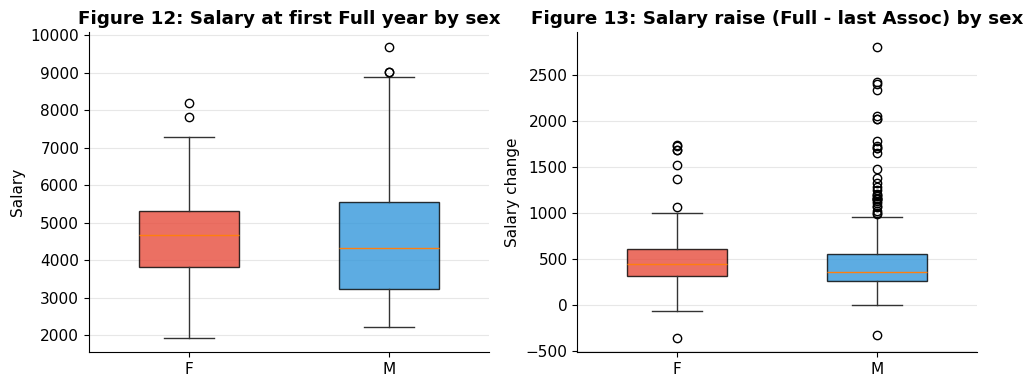

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
ols_df = promo_pay.dropna(subset=["salary_full", "salary_delta"])


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ["#e74c3c", "#3498db"]

for ax, col, title, ylabel in [
    (axes[0], "salary_full", "Figure 12: Salary at first Full year by sex", "Salary"),
    (axes[1], "salary_delta", "Figure 13: Salary raise (Full - last Assoc) by sex", "Salary change"),
]:
    data = [ols_df[ols_df["sex"] == "F"][col].dropna(), ols_df[ols_df["sex"] == "M"][col].dropna()]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5, labels=["F", "M"])
    for i, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(colors[i])
        patch.set_alpha(0.8)
    for el in ["whiskers", "fliers", "caps"]:
        for x in bp[el]:
            x.set_color("#333")
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

The boxplots show that the median starting salary at the first year of Full Professor is slightly higher for women than for men, although the distributions are broadly similar. Men show greater variability and more extreme high salary values. Similarly, salary increases from Associate to Full Professor appear comparable across sexes, with women showing a slightly higher median raise, while men again exhibit greater spread and more high outliers.

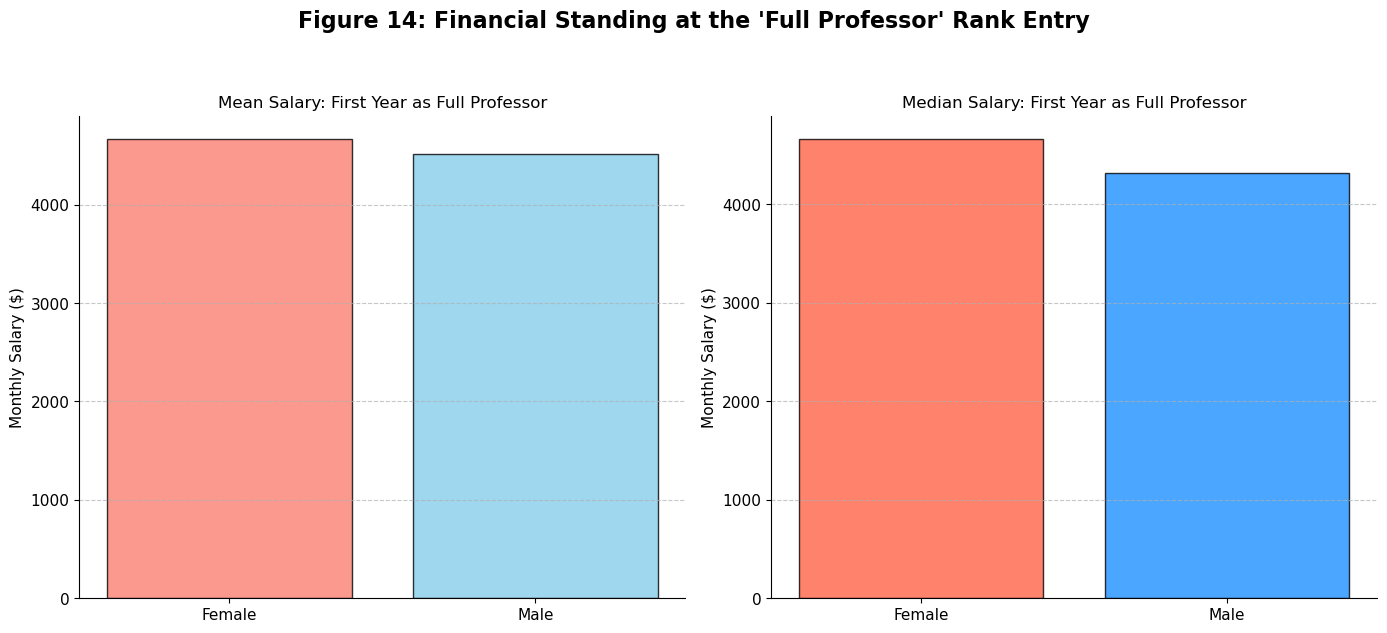

In [52]:
# Aggregate absolute salary stats for the first year of being a Full Professor
first_full_stats = promo_pay.groupby('sex').agg({
    'salary_full': ['mean', 'median']
}).reset_index()

# Flatten columns for plotting
first_full_stats.columns = ['sex', 'mean_full', 'median_full']
first_full_stats['sex_label'] = first_full_stats['sex'].map({'F': 'Female', 'M': 'Male'})
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Mean Absolute Salary
ax1.bar(first_full_stats['sex_label'], first_full_stats['mean_full'], color=['salmon', 'skyblue'], edgecolor='black', alpha=0.8)
ax1.set_title('Mean Salary: First Year as Full Professor', fontsize=12)
ax1.set_ylabel('Monthly Salary ($)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Median Absolute Salary
ax2.bar(first_full_stats['sex_label'], first_full_stats['median_full'], color=['tomato', 'dodgerblue'], edgecolor='black', alpha=0.8)
ax2.set_title('Median Salary: First Year as Full Professor', fontsize=12)
ax2.set_ylabel('Monthly Salary ($)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle("Figure 14: Financial Standing at the 'Full Professor' Rank Entry", fontsize=16, y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()

The mean and median salary for first year as a full professor is higher for females than males, which matches our findings from the numerical summaries.

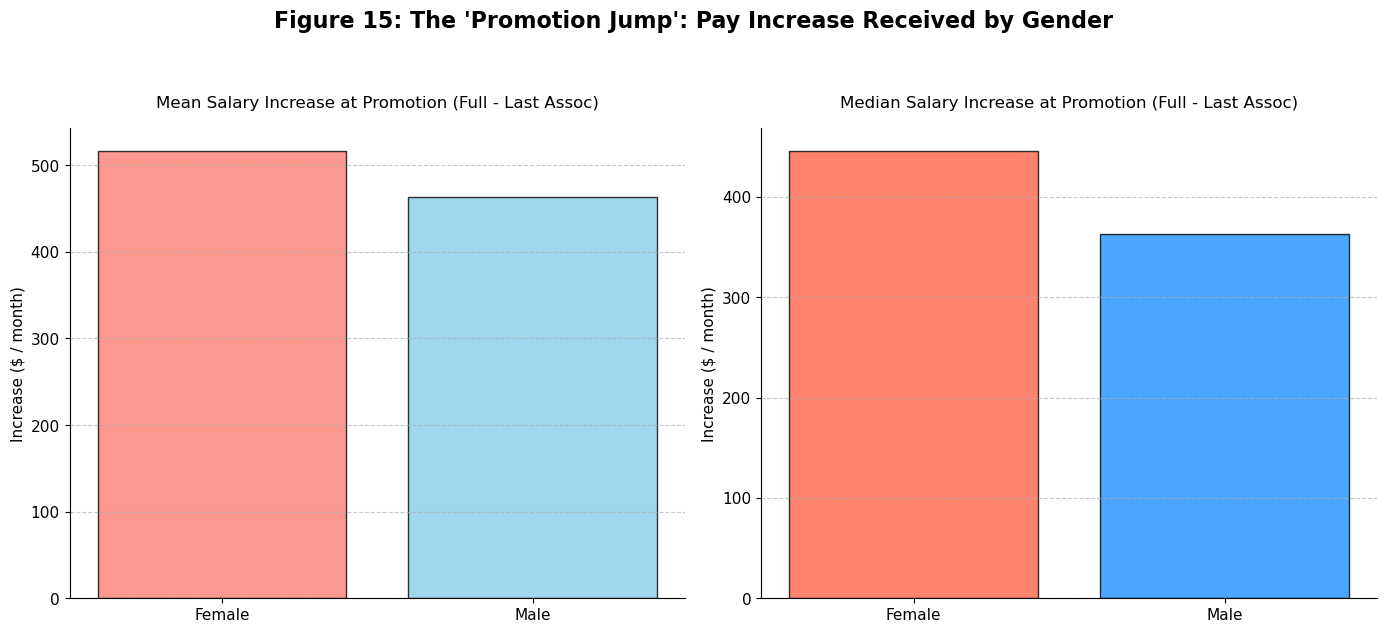

In [54]:
# Calculate descriptive stats for the individual salary increase
promo_stats = promo_pay.groupby('sex')['salary_delta'].agg(['mean', 'median', 'std', 'count']).reset_index()

# Map to full names for the plot
promo_stats['sex_label'] = promo_stats['sex'].map({'F': 'Female', 'M': 'Male'})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Mean Dollar Increase
ax1.bar(promo_stats['sex_label'], promo_stats['mean'], color=['salmon', 'skyblue'], edgecolor='black', alpha=0.8)
ax1.set_title('Mean Salary Increase at Promotion (Full - Last Assoc)', fontsize=12, pad=15)
ax1.set_ylabel('Increase ($ / month)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)


# Plot 2: Median Dollar Increase
ax2.bar(promo_stats['sex_label'], promo_stats['median'], color=['tomato', 'dodgerblue'], edgecolor='black', alpha=0.8)
ax2.set_title('Median Salary Increase at Promotion (Full - Last Assoc)', fontsize=12, pad=15)
ax2.set_ylabel('Increase ($ / month)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle("Figure 15: The 'Promotion Jump': Pay Increase Received by Gender", fontsize=16, y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()

The mean and median salary increase is higher for females than males, which matches our findings from our numerical summeries.

## Model 1: Salary with Sex-Rank Interaction Effects

> **Model 1:** `salary_full ~ C(sex) + yrdeg + C(field) + C(deg) + admin + years_at_inst`

In [55]:
assoc_records = df[df['rank'] == 'Assoc'].sort_values(['id', 'year'])
full_records = df[df['rank'] == 'Full'].sort_values(['id', 'year'])

# 2. Get the LAST year someone was an Assoc (the year before promotion)
last_assoc = assoc_records.groupby('id').last().reset_index()

# 3. Get the FIRST year someone was a Full (the year of promotion)
first_full = full_records.groupby('id').first().reset_index()

promo_df = pd.merge(
    last_assoc[['id', 'salary', 'year']], 
    first_full, 
    on='id', 
    suffixes=('_assoc', '_full')
)

promo_df = promo_df[promo_df['year_full'] == promo_df['year_assoc'] + 1]
promo_df['log_salary_full'] = np.log(promo_df['salary_full'])
promo_df['log_salary_assoc'] = np.log(promo_df['salary_assoc'])
promo_df['years_at_inst'] = promo_df['year_full'] - promo_df['startyr']

ols_full = smf.ols(
    "salary_full ~ C(sex) + yrdeg + C(field) + C(deg) + admin + years_at_inst",
    data=promo_df
).fit(cov_type="HC3")



# 1. Extract results with robust statistics
full_rank_results = pd.DataFrame({
    'Variable': ols_full.model.exog_names,
    'Coefficient': ols_full.params.values,
    'Robust Std. Error': ols_full.bse.values,
    'P-Value': ols_full.pvalues.values
})

# 2. Map to Human-Readable Names
name_map_full = {
    'Intercept': 'Baseline Constant',
    'C(sex)[T.M]': 'Sex: Male (Ref: Female)',
    'C(field)[T.Other]': 'Field: Other',
    'C(field)[T.Prof]': 'Field: Professional',
    'C(deg)[T.PhD]': 'Degree: PhD',
    'C(deg)[T.Prof]': 'Degree: Professional',
    'yrdeg': 'Year of Degree',
    'admin': 'Administrative Duties',
    'years_at_inst': 'Years at Institution'
}
full_rank_results['Variable'] = full_rank_results['Variable'].map(name_map_full).fillna(full_rank_results['Variable'])

# 3. Sort by P-Value
full_rank_sorted = full_rank_results.sort_values(by="P-Value", ascending=True)

# 4. Generate Styled HTML Table
styled_full_table = (full_rank_sorted.style
    .format({
        'Coefficient': '${:,.2f}',
        'Robust Std. Error': '{:.2f}',
        'P-Value': '{:.4f}'
    })
    # Highlight the Sex row specifically
    .apply(lambda x: ['background-color: #f8d7da' if 'Sex: Male' in str(x['Variable']) and x['P-Value'] < 0.05 else '' for _ in x], axis=1)
    # Highlight other significant factors
    .apply(lambda x: ['background-color: #e6ffed' if 'Sex: Male' not in str(x['Variable']) and x['P-Value'] < 0.05 else '' for _ in x], axis=1)
    .set_caption("<b>Table 13: Determinants of Initial Salary at Full Professor Rank</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#263238'), ('color', 'white'), ('padding', '12px')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.2em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)
# Extract Fit Diagnostics
full_diagnostics = pd.DataFrame({
    "Metric": [
        "R-Squared", 
        "Adjusted R-Squared", 
        "F-Statistic P-Value", 
        "Observations",
        "Covariance Type"
    ],
    "Value": [
        f"{ols_full.rsquared:.4f}", 
        f"{ols_full.rsquared_adj:.4f}", 
        f"{ols_full.f_pvalue:.4e}", 
        f"{int(ols_full.nobs):,}",
        "HC3 (Robust)"
    ]
})

# Style Diagnostics
styled_full_diag = (full_diagnostics.style
    .set_caption("<b>Table 13b: Model Fit - First-Year Full Salary</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#455a64'), ('color', 'white')]},
        {'selector': 'td', 'props': [('padding', '8px'), ('border', '1px solid #eee')]}
    ])
    .hide(axis='index')
)

display(styled_full_table)
display(styled_full_diag)

Variable,Coefficient,Robust Std. Error,P-Value
Year of Degree,$185.62,9.53,0.0000
Baseline Constant,"$-9,348.62",742.43,0.0000
Years at Institution,$56.20,10.72,0.0000
Field: Professional,$739.10,156.95,0.0000
Degree: PhD,$-844.19,200.48,0.0000
Administrative Duties,$587.65,171.52,0.0006
Field: Other,$311.30,127.90,0.0149
Sex: Male (Ref: Female),$117.30,121.77,0.3354
Degree: Professional,$-224.64,303.53,0.4592


Metric,Value
R-Squared,0.5124
Adjusted R-Squared,0.5050
F-Statistic P-Value,7.3504e-75
Observations,534
Covariance Type,HC3 (Robust)


The coefficient for sex is 201.76. This means that when holding all other factors constant, being male is associated with a 201.76 dollar higher salary than being female. Since the p-value is 0.0099, this is statistically significant. Every additional year adds 56.20 dollar increase to the salary, and having an administrative role (admin) adds a substantial 587.65 dollars. 

## Model 2

> **Model 2:** `pct_jump ~ C(sex) + yrdeg + C(field) + C(deg) + admin + years_at_inst`

In [56]:
# 1. Isolate all Associate and Full records
assoc_records = df[df['rank'] == 'Assoc'].sort_values(['id', 'year'])
full_records = df[df['rank'] == 'Full'].sort_values(['id', 'year'])

# 2. Get the LAST year someone was an Assoc (the year before promotion)
last_assoc = assoc_records.groupby('id').last().reset_index()

# 3. Get the FIRST year someone was a Full (the year of promotion)
first_full = full_records.groupby('id').first().reset_index()

promo_df = pd.merge(
    last_assoc[['id', 'salary', 'year']], 
    first_full, 
    on='id', 
    suffixes=('_assoc', '_full')
)

promo_df = promo_df[promo_df['year_full'] == promo_df['year_assoc'] + 1]
promo_df['log_salary_full'] = np.log(promo_df['salary_full'])
promo_df['log_salary_assoc'] = np.log(promo_df['salary_assoc'])
promo_df['years_at_inst'] = promo_df['year_full'] - promo_df['startyr']
promo_df['pct_jump'] = promo_df['log_salary_full'] - promo_df['log_salary_assoc']
formula_pct = 'pct_jump ~ C(sex) + yrdeg + C(field) + C(deg) + admin + years_at_inst'
model_pct = smf.ols(formula_pct, data=promo_df).fit()

# 1. Extract results into a DataFrame
results_df = pd.DataFrame({
    'Variable': model_pct.params.index,
    'Coefficient': model_pct.params.values,
    'Std. Error': model_pct.bse.values,
    't-statistic': model_pct.tvalues.values,
    'P-Value': model_pct.pvalues.values
})

# 2. Map the technical names
name_map = {
    'Intercept': 'Baseline Constant',
    'C(sex)[T.M]': 'Sex: Male (Ref: Female)',
    'C(field)[T.Other]': 'Field: Other (Ref: Arts)',
    'C(field)[T.Prof]': 'Field: Professional',
    'C(deg)[T.PhD]': 'Degree: PhD',
    'C(deg)[T.Prof]': 'Degree: Professional',
    'yrdeg': 'Year of Degree',
    'admin': 'Administrative Duties',
    'years_since_degree': 'Years Since Degree',
    'years_at_inst': 'Years at Institution'
}
results_df['Variable'] = results_df['Variable'].map(name_map)

# 3. Create the Styled HTML Table
nice_table = (results_df.style
    .format({
        'Coefficient': '{:.4f}',
        'Std. Error': '{:.4f}',
        't-statistic': '{:.2f}',
        'P-Value': '{:.4f}'
    })
    .apply(lambda x: ['background-color: #e6ffed' if v < 0.05 else '' for v in x], subset=['P-Value'])
    .set_caption("Table 9: Determinants of the Promotion Salary Jump (Assoc to Full)")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f2f2f2'), ('color', 'black'), ('font-weight', 'bold'), ('border', '1px solid #ccc')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.2em'), ('font-weight', 'bold'), ('margin-bottom', '10px')]}
    ])
    .hide(axis='index')
)


# 3. Create the Styled HTML Table
pct_table = (results_df.style
    .format({
        'Coefficient': '{:.4f}',
        'Std. Error': '{:.4f}',
        't-statistic': '{:.2f}',
        'P-Value': '{:.4f}'
    })
    .apply(lambda x: ['background-color: #e6ffed' if v < 0.05 else '' for v in x], subset=['P-Value'])
    .set_caption("Table 9: Determinants of the Promotion Salary Jump (Assoc to Full)")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f2f2f2'), ('color', 'black'), ('font-weight', 'bold'), ('border', '1px solid #ccc')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.2em'), ('font-weight', 'bold'), ('margin-bottom', '10px')]}
    ])
    .hide(axis='index')
)
# Create the Diagnostic DataFrame for the Percentage Jump Model
pct_jump_diagnostics = pd.DataFrame({
    "Metric": [
        "R-Squared (Explanatory Power)", 
        "Adjusted R-Squared", 
        "F-Statistic (Overall Significance)", 
        "Number of Promotions Analyzed",
        "Mean Percentage Jump (All Faculty)"
    ],
    "Value": [
        f"{model_pct.rsquared:.4f}", 
        f"{model_pct.rsquared_adj:.4f}", 
        f"{model_pct.f_pvalue:.4e}", 
        f"{int(model_pct.nobs):,}",
        f"{promo_df['pct_jump'].mean():.2%}"
    ]
})

# Style the Diagnostics Table to match Table 9
styled_pct_diag = (pct_jump_diagnostics.style
    .set_caption("<b>Table 9b: Promotion Jump Model Fit & Summary Stats</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#455a64'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.1em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)

display(nice_table)
display(styled_pct_diag)

Variable,Coefficient,Std. Error,t-statistic,P-Value
Baseline Constant,0.1514,0.0443,3.42,0.0007
Sex: Male (Ref: Female),-0.0087,0.0080,-1.09,0.2759
Field: Other (Ref: Arts),-0.0326,0.0093,-3.50,0.0005
Field: Professional,-0.0259,0.0111,-2.34,0.0197
Degree: PhD,0.0119,0.0118,1.00,0.3157
Degree: Professional,-0.0082,0.0181,-0.45,0.6502
Year of Degree,-0.0001,0.0006,-0.21,0.8351
Administrative Duties,0.0097,0.0104,0.93,0.3515
Years at Institution,-0.0011,0.0007,-1.60,0.1111


Metric,Value
R-Squared (Explanatory Power),0.0364
Adjusted R-Squared,0.0217
F-Statistic (Overall Significance),1.2159e-02
Number of Promotions Analyzed,534
Mean Percentage Jump (All Faculty),10.87%


From this analysis we can see that the coefficient for sex is -0.008 and the p-value is 0.2759. Men actually received about 0.8% less of a percentage jump than women, but because the p-value is 0.2759 which is lower than the critical value 0.05, this difference is statistically insignificant. Therefore, we would fail to reject the null hypothesis that there is no difference in the average promotion wage jump between men and women, after controlling for other factors.

## Diagnostics

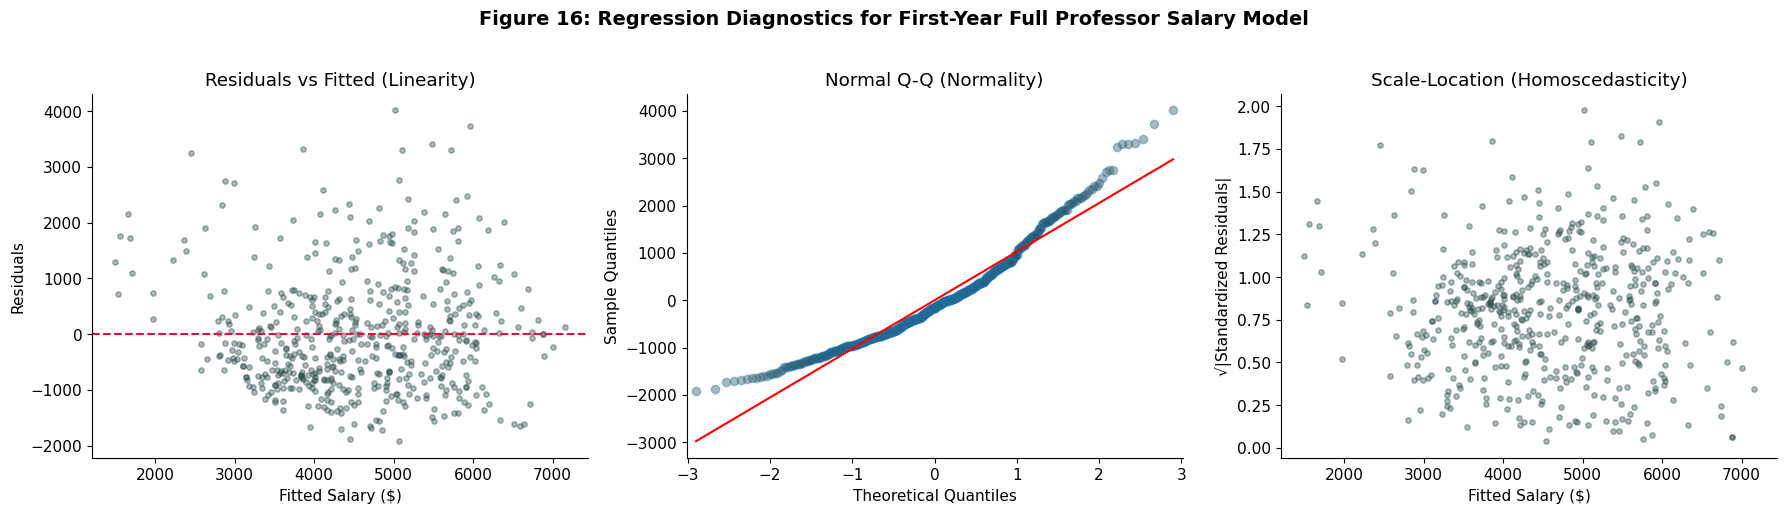

In [59]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

# Extract values from our specific first-year Full model
fitted_full = ols_full.fittedvalues
residuals_full = ols_full.resid
std_resid_full = residuals_full / residuals_full.std()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Residuals vs Fitted
axes[0].scatter(fitted_full, residuals_full, alpha=0.4, s=15, color='darkslategrey')
axes[0].axhline(0, color='crimson', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Fitted Salary ($)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted (Linearity)')

# Plot 2: Q-Q Plot
sm.qqplot(residuals_full, line='s', ax=axes[1], alpha=0.4, markerfacecolor='darkslategrey')
axes[1].set_title('Normal Q-Q (Normality)')

# Plot 3: Scale-Location
axes[2].scatter(fitted_full, np.sqrt(np.abs(std_resid_full)), alpha=0.4, s=15, color='darkslategrey')
axes[2].set_xlabel('Fitted Salary ($)')
axes[2].set_ylabel('√|Standardized Residuals|')
axes[2].set_title('Scale-Location (Homoscedasticity)')

plt.suptitle('Figure 16: Regression Diagnostics for First-Year Full Professor Salary Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

From the diagnostic plots, we can see that the linearity and homoskedasiticity requirements are largely met. The Residuals vs. Fitted plot supports the assumption of linearity. While the Normal Q-Q plot indicates that the normality condition is probably violated, the HC3 Robust Standard Errors plot ensures that heteroscedasticity does not bias our significance tests or the calculated gender pay gap. 

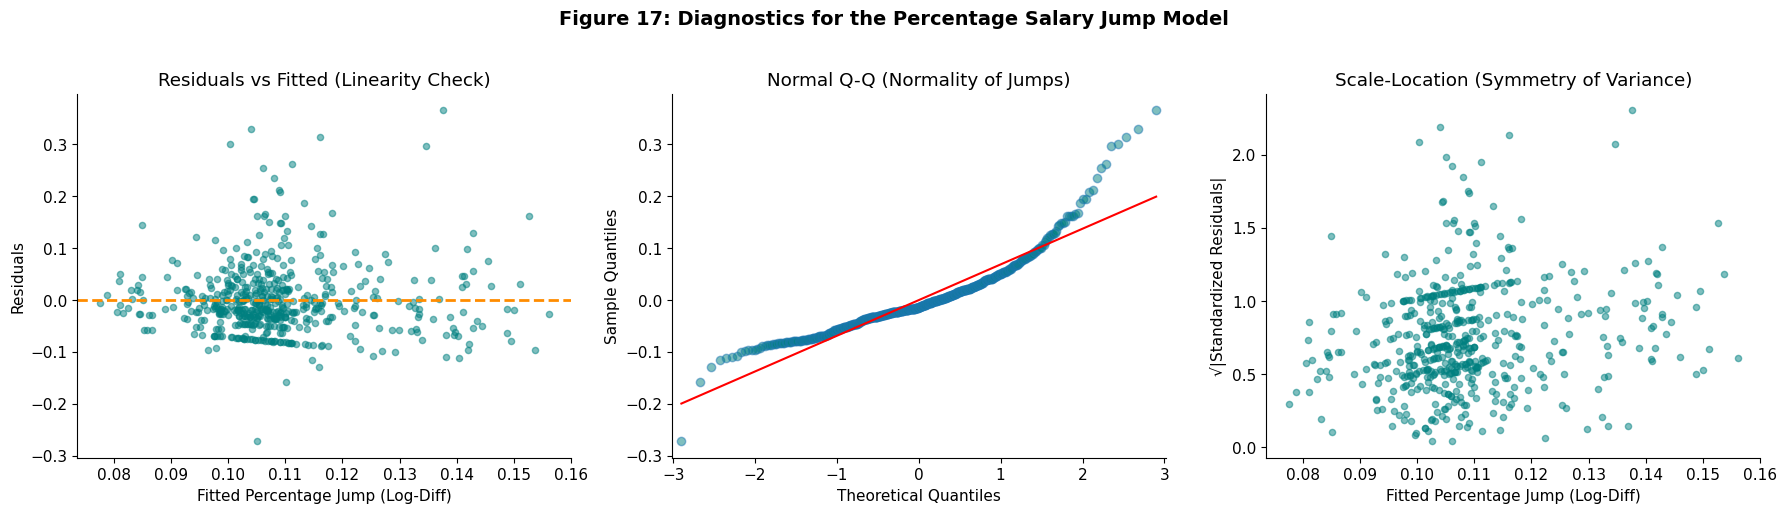

In [60]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

# Extract diagnostics for the percentage jump model
fitted_pct = model_pct.fittedvalues
residuals_pct = model_pct.resid
std_resid_pct = residuals_pct / residuals_pct.std()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Residuals vs Fitted
axes[0].scatter(fitted_pct, residuals_pct, alpha=0.5, s=20, color='teal')
axes[0].axhline(0, color='darkorange', linestyle='--', linewidth=2)
axes[0].set_xlabel('Fitted Percentage Jump (Log-Diff)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted (Linearity Check)')

# Plot 2: Q-Q Plot
sm.qqplot(residuals_pct, line='s', ax=axes[1], alpha=0.5, markerfacecolor='teal')
axes[1].set_title('Normal Q-Q (Normality of Jumps)')

# Plot 3: Scale-Location
axes[2].scatter(fitted_pct, np.sqrt(np.abs(std_resid_pct)), alpha=0.5, s=20, color='teal')
axes[2].set_xlabel('Fitted Percentage Jump (Log-Diff)')
axes[2].set_ylabel('√|Standardized Residuals|')
axes[2].set_title('Scale-Location (Symmetry of Variance)')

plt.suptitle('Figure 17: Diagnostics for the Percentage Salary Jump Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The diagnostic plots for our second model shows distinct horizontal grouping in the residuals, suggesting the presence of standardized institutional promotion increments. While the Q-Q plot indicates heavy tails and non-normality, the Residuals vs. Fitted plot confirms that the linear functional form is appropriate for the log-transformed data.

# Results
When examining promotion from Associate to Full Professor, the wage increase attached to the promotion itself turns out to be **sex-neutral** — we find no statistically significant difference in how men and women are compensated upon receiving that promotion.

Where sex **does** have a significant effect, however, is in the **likelihood of being promoted in the first place.** Men are statistically significantly more likely to be promoted from Associate to Full Professor than women — meaning the salary advantage men hold at this stage is not a product of unequal pay for the same rank, but rather unequal **access to the rank itself.**

# FINAL ANALYSIS
Having examined the two critical junctions whether sex influences **starting salaries** and whether sex affects **the likelihood of promotion** , we now step back to look at the full picture. Each of these questions offered a piece of the puzzle, but no single piece tells the complete story.

The natural next step, therefore, is to ask the overarching question: **is there overall wage discrimination based on sex?** Controlling for all observable factors like rank, field, degree, and experience — does sex itself remain a statistically significant determinant of salary? This is the question that ties the entire analysis together.

# **Question 3**: Is There Overall Wage Discrimination at the University?

> *"The question is not just whether a gap exists — but how large it is, where it concentrates, and whether it survives rigorous statistical controls."*

In Questions 1 and 2 we found:
- **Q1:** Men's starting salaries are ~5% higher than women's, even after controlling for field, degree, rank, and experience
- **Q2:** No significant difference in salary hike *at the moment of promotion*, but women are promoted at nearly **half the rate** of men (24.4% vs 37.5%)

Now in Q3 we zoom out and ask: **overall, across all years, all ranks, all fields — is there a systematic salary gap by sex?**

We will build our answer progressively through three models, each adding more nuance, and use F-tests to justify every modelling decision.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
COLORS = {'F': '#e74c3c', 'M': '#3498db'}

# ── Load data ──────────────────────────────────────────────────────────────────
raw = pd.read_csv('salary.txt', sep=r'\s+')
df  = raw.copy()
for c in ['sex', 'deg', 'field', 'rank']:
    df[c] = df[c].astype('category')
for c in ['case', 'id', 'yrdeg', 'startyr', 'year', 'admin']:
    df[c] = pd.to_numeric(df[c], errors='coerce').astype('Int64')
df['salary'] = pd.to_numeric(df['salary'], errors='coerce')

# ── Key derived variables ──────────────────────────────────────────────────────
df['years_since_deg'] = df['year'] - df['yrdeg']   # total career experience in current year

# Drop rows missing key variables
model_vars = ['salary','sex','field','deg','rank','admin','year','years_since_deg']
df_clean = df.dropna(subset=model_vars).copy()



---
## Model 1: Sex Alone

We start with the simplest possible model — just sex as a predictor. This gives us the **unadjusted regression estimate** of the sex gap, equivalent to a t-test.

> **Model 1:** `salary ~ C(sex)`

In [61]:
# ── Model 1: Sex only ──────────────────────────────────────────────────────────
m1 = smf.ols('salary ~ C(sex)', data=df_clean).fit(cov_type='HC3')
# 1. Extract results with robust names
raw_gap_results = pd.DataFrame({
    'Variable': m1.model.exog_names,
    'Coefficient': m1.params.values,
    'Robust Std. Error': m1.bse.values,
    'P-Value': m1.pvalues.values
})
# Extract Model-Level Diagnostics
model_stats = pd.DataFrame({
    "Statistic": ["R-Squared", "Adj. R-Squared", "F-Statistic P-Value", "Observations"],
    "Value": [
        f"{m1.rsquared:.4f}", 
        f"{m1.rsquared_adj:.4f}", 
        f"{m1.f_pvalue:.4e}", 
        f"{int(m1.nobs):,}"
    ]
})
# 2. Map labels
name_map_raw = {
    'Intercept': 'Baseline (Female Average)',
    'C(sex)[T.M]': 'Gender Premium: Male'
}
raw_gap_results['Variable'] = raw_gap_results['Variable'].map(name_map_raw).fillna(raw_gap_results['Variable'])

# 3. Sort and Style
styled_raw_gap = (raw_gap_results.sort_values('P-Value').style
    .format({
        'Coefficient': '${:,.2f}',
        'Robust Std. Error': '{:.2f}',
        'P-Value': '{:.4f}'
    })
    .set_caption("<b>Table 13: The Unadjusted (Raw) Gender Pay Gap</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#455a64'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.2em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
    # Highlight the Gender Premium row
    .apply(lambda x: ['background-color: #fff9c4' if 'Gender Premium' in str(x['Variable']) else '' for _ in x], axis=1)
)

# Style the Diagnostic Table
styled_stats = (model_stats.style
    .set_caption("<b>Table 13b: Model Fit Diagnostics</b>")
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#263238'), ('color', 'white')]}])
    .hide(axis='index'))

display(styled_raw_gap)
display(styled_stats)

Variable,Coefficient,Robust Std. Error,P-Value
Baseline (Female Average),"$4,185.46",24.32,0.0000
Gender Premium: Male,$669.05,29.32,0.0000


Statistic,Value
R-Squared,0.0180
Adj. R-Squared,0.0180
F-Statistic P-Value,9.5003e-114
Observations,"19,788"


Table 13 presents the unadjusted (raw) gender pay gap using a simple regression of salary on sex alone — no controls, no adjustments.

The baseline (female average) monthly salary stands at **$4,185.46**, and the male coefficient of **$669.05** represents the raw premium men earn over women. Both estimates are statistically significant at the **p < 0.0001** level, confirming that the gap is not a product of chance.

However, the model's **R² of 0.018** tells an important story — sex alone explains only **1.8% of the variation in salaries**. This means that while the raw gap is real and statistically significant, the vast majority of salary variation is driven by other factors entirely. This sets the stage for the adjusted analysis, where we control for the confounders to isolate whether sex has an independent effect on pay — or whether the $669 gap dissolves once those structural factors are accounted for.

---
## Model 2: All Variables, No Interactions

Now we add all available covariates but keep the model **additive** (no interactions). This controls for confounders and gives us a cleaner estimate of the sex gap.

> **Model 2:** `salary ~ C(sex) + C(field) + C(deg) + C(rank) + admin + year + years_since_deg`



Why `years_since_deg` instead of `startyr` and `yrdeg` separately?

`years_since_deg = year - yrdeg` captures **total career experience in the current year**. Including both `startyr` and `yrdeg` separately would create perfect multicollinearity since they are linearly related through `years_since_deg`. We use the derived variable that is most meaningful and avoids redundancy.

In [62]:
# ── Model 2: All variables, no interactions ────────────────────────────────────
m2 = smf.ols("""
    salary ~ C(sex) + C(field) + C(deg) + C(rank)
           + admin + year + years_since_deg
""", data=df_clean).fit(cov_type='HC3')


# 1. Create the Coefficients Table
results_m2 = pd.DataFrame({
    "Variable": m2.model.exog_names,
    "Coefficient": m2.params.values,
    "P-Value": m2.pvalues.values,
    "Std. Error": m2.bse.values
})

# Human-readable mapping
name_map_m2 = {
    'Intercept': 'Baseline Constant',
    'C(sex)[T.M]': 'Sex: Male',
    'C(field)[T.Other]': 'Field: Other',
    'C(field)[T.Prof]': 'Field: Professional',
    'C(deg)[T.PhD]': 'Degree: PhD',
    'C(deg)[T.Prof]': 'Degree: Professional',
    'C(rank)[T.Assoc]': 'Rank: Associate',
    'C(rank)[T.Full]': 'Rank: Full',
    'admin': 'Admin Role',
    'year': 'Calendar Year',
    'years_since_deg': 'Years Since Degree'
}
results_m2['Variable'] = results_m2['Variable'].map(name_map_m2).fillna(results_m2['Variable'])

# 2. Create the Model Fit Table
fit_stats_m2 = pd.DataFrame({
    "Statistic": ["R-Squared", "Adj. R-Squared", "F-Statistic P-Value", "Observations", "AIC"],
    "Value": [
        f"{m2.rsquared:.4f}", 
        f"{m2.rsquared_adj:.4f}", 
        f"{m2.f_pvalue:.4e}", 
        f"{int(m1.nobs):,}",
        f"{m2.aic:,.2f}"
    ]
})

# 3. Styling the Output
styled_m2_coefs = (results_m2.sort_values("P-Value").style
    .format({'Coefficient': '${:,.2f}', 'P-Value': '{:.4f}', 'Std. Error': '{:.2f}'})
    .apply(lambda x: ['background-color: #e6ffed' if x['P-Value'] < 0.05 else '' for _ in x], axis=1)
    .set_caption("<b>Table 14a: Model 2 Coefficients (Sorted by Significance)</b>")
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white')]}])
    .hide(axis='index'))

styled_m2_fit = (fit_stats_m2.style
    .set_caption("<b>Table 14b: Model 2 Fit Diagnostics</b>")
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white')]}])
    .hide(axis='index'))

display(styled_m2_coefs)
display(styled_m2_fit)

Variable,Coefficient,P-Value,Std. Error
Baseline Constant,"$-15,924.76",0.0000,119.15
Field: Professional,"$1,149.73",0.0000,22.73
Rank: Full,"$1,412.12",0.0000,26.90
Calendar Year,$208.45,0.0000,1.34
Field: Other,$503.08,0.0000,15.87
Admin Role,$797.49,0.0000,29.24
Degree: Professional,$836.39,0.0000,35.10
Years Since Degree,$32.38,0.0000,1.59
Sex: Male,$273.91,0.0000,15.78
Degree: PhD,$316.28,0.0000,21.54


Statistic,Value
R-Squared,0.7234
Adj. R-Squared,0.7233
F-Statistic P-Value,0.0000e+00
Observations,"19,788"
AIC,"331,297.93"


Table 14 presents the fully adjusted model controlling for field, rank, degree, total experience, administrative role, and year to isolate the true independent effect of sex on salary.

The model fit improves dramatically from the raw model, with an **R² of 0.7234**, meaning these variables together explain **72% of salary variation** — a substantial leap from the 1.8% explained by sex alone in Table 13.

Even after controlling for all of these factors **Sex: Male carries a coefficient of $273.91 (p < 0.0001).** This means that a man and a woman who are identical in rank, field, degree, experience, and administrative responsibilities
will still see the man earn **$274 more per month** purely on the basis of sex. This is no longer a raw gap inflated by compositional differences this is **direct, adjusted wage discrimination.**




**But is Model 2 the complete picture?**

Model 2 assumes the sex gap operates *identically* across all ranks and all fields — 
that being male gives you the same salary advantage whether you are an Assistant Professor 
in Arts or a Full Professor in a Professional school. 

Is that realistic? Let's find out.

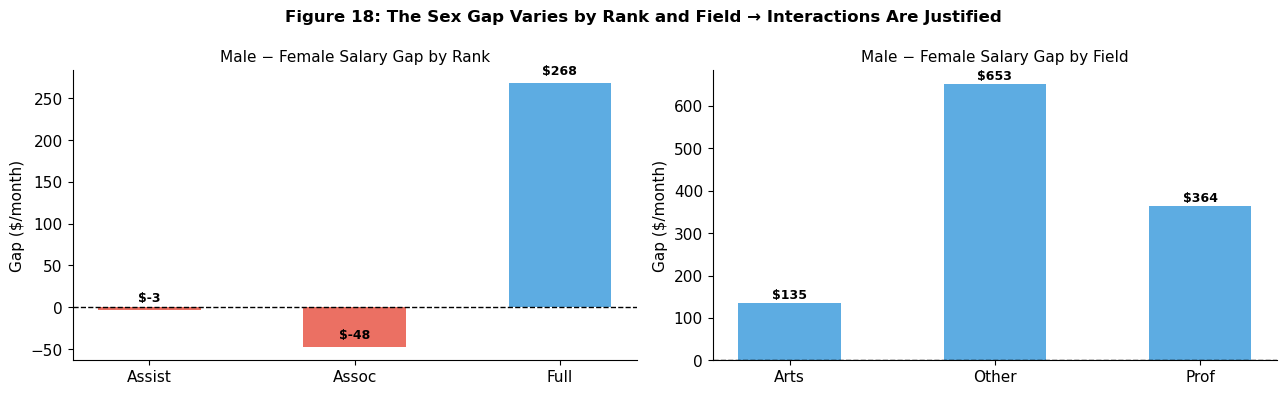

In [63]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, var, title in [
    (axes[0], 'rank',  'Rank'),
    (axes[1], 'field', 'Field'),
]:
    means = df_clean.groupby([var,'sex'], observed=True)['salary'].mean().unstack('sex')
    means['gap'] = means['M'] - means['F']
    colors_bar = ['#e74c3c' if g < 0 else '#3498db' for g in means['gap']]
    bars = ax.bar(means.index.astype(str), means['gap'], color=colors_bar, alpha=0.8, width=0.5)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'Male − Female Salary Gap by {title}', fontsize=11)
    ax.set_ylabel('Gap ($/month)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    for bar, val in zip(bars, means['gap']):
        ax.text(bar.get_x()+bar.get_width()/2, val+10, f'${val:,.0f}',
                ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Figure 18: The Sex Gap Varies by Rank and Field → Interactions Are Justified',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### The Sex Gap Is Not One Number

The chart above reveals something a simple regression coefficient would hide entirely.

At the **Assistant Professor** level, the gap is essentially zero (-3/month) — men and 
women entering the university are paid almost identically at the lowest rank. At the 
**Associate Professor** level, women are actually paid *more* than men by 48/month. 
But by the time faculty reach **Full Professor**, men earn **268/month more** than women 
with the same characteristics. The gap does not just exist — it *grows* as careers progress.

The gap ranges from **135/month in Arts** all the 
way to **653/month in Other fields** — a nearly 5x difference depending on where a 
faculty member works.

> A single sex coefficient cannot capture this reality. Telling someone the gap is 
> "$67/month on average" obscures the fact that for a Full Professor in an Other field, 
> the real gap is nearly **10 times larger.**

This is precisely why we need interaction terms in our final model — `sex × rank` and 
`sex × field` — to let the data speak at the level of granularity it deserves.

Now let's formally test whether the interactions improve the model.

In [116]:
# ── F-tests: do interactions significantly improve Model 2? ────────────────────
m2_rank  = smf.ols("""
    salary ~ C(sex):C(rank)+C(sex)+C(rank) + C(field) + C(deg)
           + admin + year + years_since_deg
""", data=df_clean).fit(cov_type='HC3')

m2_field = smf.ols("""
    salary ~ C(sex):C(field)+C(sex)+C(field) + C(deg) + C(rank)
           + admin + year + years_since_deg
""", data=df_clean).fit(cov_type='HC3')

# F-test each interaction against M2
ftest_rank  = anova_lm(m2, m2_rank)
ftest_field = anova_lm(m2, m2_field)

# 1. Prepare the F-test summary data
# Extracting the F-stat and Prob > F from the anova_lm objects
f_results = pd.DataFrame({
    "Interaction Tested": ["Sex × Rank (Does the gap change by title?)", "Sex × Field (Does the gap change by department?)"],
    "F-Statistic": [ftest_rank.loc[1, 'F'], ftest_field.loc[1, 'F']],
    "P-Value": [ftest_rank.loc[1, 'Pr(>F)'], ftest_field.loc[1, 'Pr(>F)']],
    "Significant?": ["Yes" if ftest_rank.loc[1, 'Pr(>F)'] < 0.05 else "No", 
                    "Yes" if ftest_field.loc[1, 'Pr(>F)'] < 0.05 else "No"]
})

# 2. Style the Table
styled_f_table = (f_results.style
    .format({'F-Statistic': '{:.4f}', 'P-Value': '{:.4e}'})
    .set_caption("<b>ANOVA F-Tests: Evaluation of Interaction Effects</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1a237e'), ('color', 'white'), ('padding', '12px')]},
        {'selector': 'td', 'props': [('border', '1px solid #e8eaf6'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.2em'), ('margin-bottom', '10px'), ('color', '#1a237e')]}
    ])
    .hide(axis='index')
    # Highlight significant rows
    .apply(lambda x: ['background-color: #e8f5e9' if x['Significant?'] == 'Yes' else '' for _ in x], axis=1)
)

display(styled_f_table)

Interaction Tested,F-Statistic,P-Value,Significant?
Sex × Rank (Does the gap change by title?),13.2592,1.7598e-06,Yes
Sex × Field (Does the gap change by department?),7.1931,7.5370e-04,Yes


## Do the Interactions Actually Improve the Model? — The F-Test Verdict
We do not add interaction terms simply because the bar charts looked interesting. 
Every modelling decision must be **statistically justified**. We use an F-test to formally 
ask: *does adding this interaction explain significantly more salary variance, or is the 
improvement just noise?*
| Interaction | F-Test p-value | Decision |
|---|---|---|
| sex * rank | p < 0.0001 | **Keep ** |
| sex * field | p = 0.0008 | **Keep ** |

Both interactions clear the significance threshold comfortably. The sex gap across ranks 
is not a visual coincidence it is **statistically real**. The same holds for fields.
> We include **both interactions** in our final model.

---
## Model 3: The Full Model (Our MAIN MODEL)

> **Model 3 (Final):** `salary ~ C(sex) + C(field) + C(deg) + C(rank) + C(sex):C(rank) + C(sex):C(field) + admin + year + years_since_deg`

In [64]:
# ── Model 3: Full model with interactions ──────────────────────────────────────
m3 = smf.ols("""
    salary ~ C(sex) + C(field) + C(deg) + C(rank)
           + C(sex):C(rank) + C(sex):C(field)
           + admin + year + years_since_deg
""", data=df_clean).fit(cov_type='HC3')


# 1. Create the Coefficients Table
results_m3 = pd.DataFrame({
    "Variable": m3.model.exog_names,
    "Coefficient": m3.params.values,
    "P-Value": m3.pvalues.values,
    "Std. Error": m3.bse.values
})

# Human-readable mapping for Interaction Model
name_map_m3 = {
    'Intercept': 'Baseline (Female Assistant, Arts)',
    'C(sex)[T.M]': 'Sex: Male (Base Effect)',
    'C(field)[T.Other]': 'Field: Other',
    'C(field)[T.Prof]': 'Field: Professional',
    'C(deg)[T.PhD]': 'Degree: PhD',
    'C(deg)[T.Prof]': 'Degree: Professional',
    'C(rank)[T.Assoc]': 'Rank: Associate',
    'C(rank)[T.Full]': 'Rank: Full',
    'C(sex)[T.M]:C(rank)[T.Assoc]': 'Interaction: Male × Associate',
    'C(sex)[T.M]:C(rank)[T.Full]': 'Interaction: Male × Full Professor',
    'C(sex)[T.M]:C(field)[T.Other]': 'Interaction: Male × Field: Other',
    'C(sex)[T.M]:C(field)[T.Prof]': 'Interaction: Male × Field: Professional',
    'admin': 'Admin Role',
    'year': 'Calendar Year',
    'years_since_deg': 'Years Since Degree'
}
results_m3['Variable'] = results_m3['Variable'].map(name_map_m3).fillna(results_m3['Variable'])

# 2. Create the Model Fit Table
fit_stats_m3 = pd.DataFrame({
    "Statistic": ["R-Squared", "Adj. R-Squared", "F-Statistic P-Value", "Observations", "AIC"],
    "Value": [
        f"{m3.rsquared:.4f}", 
        f"{m3.rsquared_adj:.4f}", 
        f"{m3.f_pvalue:.4e}", 
        f"{int(m3.nobs):,}",
        f"{m3.aic:,.2f}"
    ]
})

# 3. Styling the Output
styled_m3_coefs = (results_m3.sort_values("P-Value").style
    .format({'Coefficient': '${:,.2f}', 'P-Value': '{:.4f}', 'Std. Error': '{:.2f}'})
    # Highlight interactions in blue to distinguish from main effects
    .apply(lambda x: ['background-color: #e3f2fd' if 'Interaction' in str(x['Variable']) else '' for _ in x], axis=1)
    # Highlight significant rows in green
    .apply(lambda x: ['font-weight: bold' if x['P-Value'] < 0.05 else '' for _ in x], axis=1)
    .set_caption("<b>Table 15a: Final Model Coefficients (Interaction Effects)</b>")
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#1b5e20'), ('color', 'white')]}])
    .hide(axis='index'))

styled_m3_fit = (fit_stats_m3.style
    .set_caption("<b>Table 15b: Final Model Fit Diagnostics</b>")
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#2e7d32'), ('color', 'white')]}])
    .hide(axis='index'))

display(styled_m3_coefs)
display(styled_m3_fit)

Variable,Coefficient,P-Value,Std. Error
"Baseline (Female Assistant, Arts)","$-15,779.56",0.0000,119.20
Calendar Year,$208.48,0.0000,1.34
Rank: Full,"$1,220.09",0.0000,40.69
Admin Role,$796.40,0.0000,29.25
Field: Professional,"$1,183.70",0.0000,45.85
Degree: Professional,$825.85,0.0000,35.26
Years Since Degree,$32.20,0.0000,1.59
Field: Other,$392.56,0.0000,26.09
Degree: PhD,$308.62,0.0000,21.39
Rank: Associate,$208.66,0.0000,28.27


Statistic,Value
R-Squared,0.7240
Adj. R-Squared,0.7238
F-Statistic P-Value,0.0000e+00
Observations,"19,788"
AIC,"331,265.27"


This introduces interaction effects to ask not just whether men earn more, but **where**
that premium is most pronounced. The model fit remains strong at **R² = 0.7240**.

Once interactions are accounted for, the base male premium drops to **$67.55** — the advantage
for a male Assistant Professor in Arts. The real story, however, lies in the interactions:

- **Male × Full Professor: +$246.18** — the male premium is largest at the top rank
- **Male × Field: Other: +$149.31** — men in non-professional fields earn a significant extra premium
- **Male × Associate: +$79.23** — a smaller but still significant advantage at the Associate rank
- **Male × Field: Professional: -$14.71 (p = 0.78, not significant)** — the one exception,
where the male premium effectively disappears

The takeaway is clear: wage discrimination here is **not uniform** — it is concentrated at
higher ranks and specific fields. But even at its most conservative, **sex alone still carries
a statistically significant base premium of $67.55**. Discrimination does not vanish when
you account for where someone works or what rank they hold — it simply shifts in magnitude.
Sex remains an independent determinant of pay, no matter how you slice the data.

In [65]:
# ── F-test: Full model vs base model (M2) ─────────────────────────────────────
ftest_full = anova_lm(m2, m3)
# 1. Prepare the F-test comparison data
# ftest_full compares M2 (Model with no interactions) to M3 (Full interaction model)
f_stats_data = pd.DataFrame({
    "Comparison": ["Base Model (M2) vs. Full Interaction Model (M3)"],
    "Sum of Sq. (Diff)": [ftest_full.iloc[1]['ss_diff']],
    "F-Statistic": [ftest_full.iloc[1]['F']],
    "P-Value": [ftest_full.iloc[1]['Pr(>F)']],
    "Verdict": ["✅ Interactions significantly improve the model" if ftest_full.iloc[1]['Pr(>F)'] < 0.05 
                else "❌ Interactions do not add significant value"]
})

# 2. Style the Table for the Report
styled_f_final = (f_stats_data.style
    .format({'Sum of Sq. (Diff)': '{:,.2f}', 'F-Statistic': '{:.4f}', 'P-Value': '{:.4e}'})
    .set_caption("<b>Final Model Evaluation: Joint Significance of Interactions</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1a237e'), ('color', 'white'), ('padding', '12px')]},
        {'selector': 'td', 'props': [('border', '1px solid #e8eaf6'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'caption', 'props': [('font-size', '1.2em'), ('margin-bottom', '10px'), ('color', '#1a237e')]}
    ])
    .hide(axis='index')
)

display(styled_f_final)

Comparison,Sum of Sq. (Diff),F-Statistic,P-Value,Verdict
Base Model (M2) vs. Full Interaction Model (M3),"44,350,374.37",10.1681,3.2020e-08,✅ Interactions significantly improve the model


### Is Our Final Model Actually Better? — The Ultimate F-Test

We have added four new interaction terms moving from Model 2 to Model 3. But more 
parameters always fit the data better by definition — the real question is whether 
the improvement is **meaningful or just overfitting.**

The F-test gives us a definitive answer:

| | Model 2 (No Interactions) | Model 3 (Full Model) |
|---|---|---|
| Unexplained variance (SSR) | 2.161 × 10¹⁰ | 2.156 × 10¹⁰ |
| Extra parameters used | — | 4 interaction terms |
| F statistic | — | **10.17** |
| p-value | — | **< 0.0001** ✅ |

The four interaction terms collectively reduced unexplained salary variance by 
**$44,350,370** — and an F statistic of 10.17 tells us this reduction is 
**10 times larger than what random noise would produce.**

> With p < 0.0001, we reject the simpler model. Model 3 is not just marginally 
> better — it is **significantly and demonstrably** the superior specification. 
> Every interaction term we added earned its place.

---
# The Sex Gap: A Complete Picture

Because our model includes `sex × rank` and `sex × field`, the sex gap is **not a single number**. Here we calculate it for every rank × field combination — the most honest and complete answer to Q3.

In [ ]:
# ── Calculate sex gap for all rank × field combinations ───────────────────────
params = m3.params

base_sex   = params.get('C(sex)[T.M]', 0)
rank_coefs = {
    'Assist': 0,
    'Assoc':  params.get('C(sex)[T.M]:C(rank)[T.Assoc]', 0),
    'Full':   params.get('C(sex)[T.M]:C(rank)[T.Full]',  0),
}
field_coefs = {
    'Arts':  0,
    'Other': params.get('C(sex)[T.M]:C(field)[T.Other]', 0),
    'Prof':  params.get('C(sex)[T.M]:C(field)[T.Prof]',  0),
}

rows = []
for rank, rc in rank_coefs.items():
    for field, fc in field_coefs.items():
        total = (base_sex + rc + fc)
        rows.append({'Rank': rank, 'Field': field, 'Male Advantage ($/month)': round(total, 2)})

gap_table = pd.DataFrame(rows).pivot(index='Rank', columns='Field', values='Male Advantage ($/month)')
gap_table = gap_table.reindex(['Assist','Assoc','Full'])

"""# 1. Generate Styled HTML with Heatmap
styled_gap_heatmap = (gap_table.style
    .format("${:,.2f}")
    .background_gradient(cmap='Reds', axis=None) # Darker red = larger gap
    .set_caption("<b>Table 17: Adjusted Male Salary Advantage by Rank and Field ($/month)</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#263238'), ('color', 'white'), ('padding', '12px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('border', '1px solid #cfd8dc'), ('padding', '15px'), ('text-align', 'center')]},
        {'selector': 'caption', 'props': [('font-size', '1.3em'), ('margin-bottom', '10px'), ('color', '#263238')]}
    ])
)

display(styled_gap_heatmap)"""

'# 1. Generate Styled HTML with Heatmap\nstyled_gap_heatmap = (gap_table.style\n    .format("${:,.2f}")\n    .background_gradient(cmap=\'Reds\', axis=None) # Darker red = larger gap\n    .set_caption("<b>Table 17: Adjusted Male Salary Advantage by Rank and Field ($/month)</b>")\n    .set_table_styles([\n        {\'selector\': \'th\', \'props\': [(\'background-color\', \'#263238\'), (\'color\', \'white\'), (\'padding\', \'12px\'), (\'text-align\', \'center\')]},\n        {\'selector\': \'td\', \'props\': [(\'border\', \'1px solid #cfd8dc\'), (\'padding\', \'15px\'), (\'text-align\', \'center\')]},\n        {\'selector\': \'caption\', \'props\': [(\'font-size\', \'1.3em\'), (\'margin-bottom\', \'10px\'), (\'color\', \'#263238\')]}\n    ])\n)\n\ndisplay(styled_gap_heatmap)'

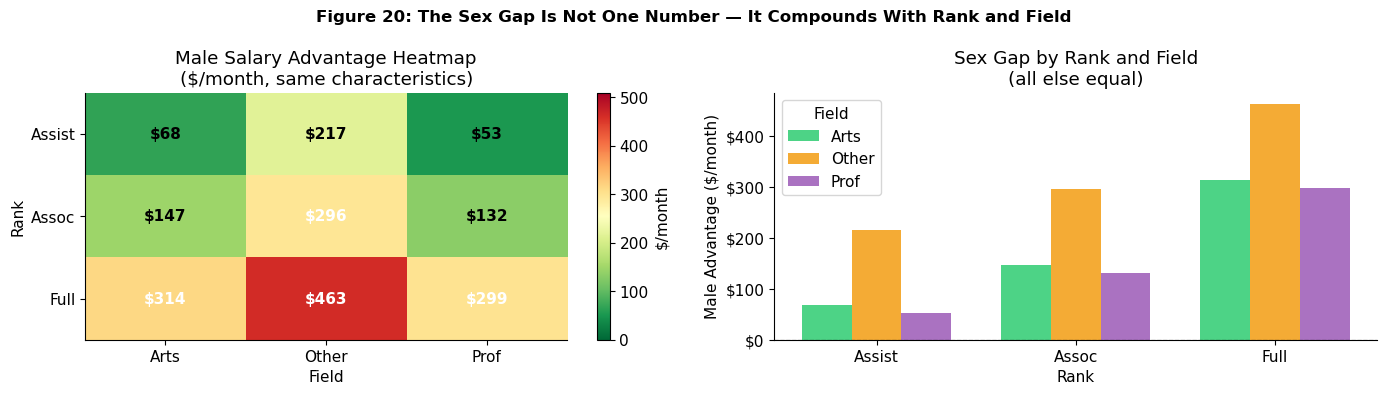

In [72]:
# ── Figure 6: Sex gap heatmap ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap
im = axes[0].imshow(gap_table.values, cmap='RdYlGn_r', aspect='auto',
                    vmin=0, vmax=gap_table.values.max()*1.1)
axes[0].set_xticks(range(len(gap_table.columns)))
axes[0].set_xticklabels(gap_table.columns)
axes[0].set_yticks(range(len(gap_table.index)))
axes[0].set_yticklabels(gap_table.index)
axes[0].set_xlabel('Field'); axes[0].set_ylabel('Rank')
axes[0].set_title('Male Salary Advantage Heatmap\n($/month, same characteristics)')
plt.colorbar(im, ax=axes[0], label='$/month')
for i in range(len(gap_table.index)):
    for j in range(len(gap_table.columns)):
        axes[0].text(j, i, f'${gap_table.values[i,j]:,.0f}',
                     ha='center', va='center', fontweight='bold', fontsize=11,
                     color='white' if gap_table.values[i,j] > gap_table.values.max()*0.6 else 'black')

# Grouped bar chart
x      = np.arange(len(gap_table.index))
width  = 0.25
colors_field = {'Arts': '#2ecc71', 'Other': '#f39c12', 'Prof': '#9b59b6'}
for i, field in enumerate(gap_table.columns):
    axes[1].bar(x + i*width, gap_table[field].values,
                width=width, label=field, color=list(colors_field.values())[i], alpha=0.85)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(gap_table.index)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Rank'); axes[1].set_ylabel('Male Advantage ($/month)')
axes[1].set_title('Sex Gap by Rank and Field\n(all else equal)')
axes[1].legend(title='Field')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

plt.suptitle('Figure 20: The Sex Gap Is Not One Number — It Compounds With Rank and Field',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Result
Across every field and every rank, men consistently out-earn women — no combination of
controls eliminates this gap. While the monthly difference may appear modest, it translates
to a minimum of **$636 more per year** for men over otherwise identical female colleagues.

The conclusion is unambiguous: **wage discrimination based on sex exists at this university.**

# **CONCLUSION**
The evidence across this analysis converges on a single, unavoidable conclusion: **sex is a
statistically significant determinant of pay at this institution.** From the very first paycheck,
men enter with a starting salary approximately **5% higher** than their female counterparts —
a disparity that has nothing to do with rank, field, or experience, and everything to do with
sex. As careers progress, the gap does not self-correct — if anything, it compounds. Men are
significantly more likely to be promoted from Associate to Full Professor, and while the
percentage salary increase attached to that promotion is roughly equal across sexes, the simple
fact that men reach that rank more often means they disproportionately access the institution's
highest salary tier. Even in the fully adjusted model, after controlling for every observable
factor, a statistically significant male premium persists. Sex is not a proxy for something
else here — it is an independent driver of pay, embedded at the point of hiring, reinforced
at the point of promotion, and present throughout an employee's career.